# Non-reversible anchored Langevin with a block state-dependent skew-symmetric matrix

Synthetic Bayesian logistic regression under two constraint sets, comparing four
samplers that share a single implementation and differ only in two parameters.

| Method | $\rho$ | $\alpha$ |
|---|---:|---:|
| Projected SGLD | $0$ | $0$ |
| Non-reversible SGLD | $0$ | $1$ |
| Reversible anchored Langevin | $\log 2$ | $0$ |
| Non-reversible anchored Langevin | $\log 2$ | $1$ |

The two anchored rows isolate the effect of non-reversibility **at a fixed anchor**;
the two $\alpha=0$ rows isolate the effect of the anchor at fixed reversibility.

**The deliverable is the measurement, not a favourable result.** Nothing here assumes
that non-reversibility or anchoring must help. The observed outcome at the paper's
candidate step size is reported as found, together with a diagnosis and a step-size
refinement that changes the conclusion.

Sections follow the requested order: configuration and seeds, data, posterior and
mini-batch gradient, constraints and projections, anchor, block matrices,
implementation checks, sampler, repeated experiments, accuracy plots, step-size
sensitivity, interpretation and limitations.

## 1. Configuration and seeds

Main settings: $d=9$, $n_{\text{total}}=2000$, stratified 80/20 split, mini-batch
$m=50$, 1000 iterations, candidate step size $h=10^{-4}$, $R=100$ replicates,
block strengths $s=(10,10,10)$, $\rho=\log 2$ for the anchored methods.

Seeds are fixed: `data_seed = 2026`, `split_seed = 2027`, `sampler_seed = 3000`.
The data set and split are frozen across every method, replicate and geometry, so
the replicate spread measures **sampler randomness only**.

Set the environment variable `NRAL_QUICK=1` before launching Jupyter to run quick
mode (5 repeats, 300 iterations). Quick-mode artefacts are written with a
`_quick` suffix and every printed table is tagged, so they can never be confused
with the full experiment.

In [1]:
import os, sys, time, json, platform, warnings
import numpy as np, pandas as pd, scipy, sklearn, matplotlib
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
import inspect

sys.path.insert(0, os.path.abspath("."))
import anchored_sgld as nral

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})

QUICK = os.environ.get("NRAL_QUICK", "0") == "1"
MODE = "QUICK MODE" if QUICK else "FULL EXPERIMENT"
SUFFIX = "_quick" if QUICK else ""
OUTPUT_DIR = "results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

cfg = nral.ExperimentConfig(
    n_repeats=5 if QUICK else 100,
    n_iterations=300 if QUICK else 1000,
    checkpoint_every=10,
    sensitivity_repeats=3 if QUICK else 20,
)
cfg_d3 = nral.ExperimentConfig(
    d=3, block_scales=(10.0,),
    n_repeats=cfg.n_repeats, n_iterations=cfg.n_iterations,
    sensitivity_repeats=cfg.sensitivity_repeats,
)

def show(obj):
    display(Markdown("```python\n" + inspect.getsource(obj) + "\n```"))

print(f"=== {MODE} ===")
print(f"d = {cfg.d}, n_total = {cfg.n_total}, n_train = {cfg.n_train}, n_test = {cfg.n_test}")
print(f"m = {cfg.batch_size}, iterations = {cfg.n_iterations}, h = {cfg.step_size}, R = {cfg.n_repeats}")
print(f"block strengths s = {tuple(float(x) for x in cfg.scales)}  (n_blocks = {cfg.n_blocks})")
print(f"rho (anchored) = log 2 = {nral.RHO_ANCHORED:.6f};  rho (unanchored) = 0")
print(f"quartic: epsilon = {cfg.epsilon}, Lambda = {cfg.Lambda}")
print(f"target accuracy for time-to-target reporting = {cfg.target_accuracy}")
print(f"\nseeds: data={cfg.data_seed}, split={cfg.split_seed}, sampler={cfg.sampler_seed}")
VERSIONS = {"python": platform.python_version(), "numpy": np.__version__,
            "scipy": scipy.__version__, "pandas": pd.__version__,
            "scikit-learn": sklearn.__version__, "matplotlib": matplotlib.__version__}
print("versions:", VERSIONS)

=== FULL EXPERIMENT ===
d = 9, n_total = 2000, n_train = 1600, n_test = 400
m = 50, iterations = 1000, h = 0.0001, R = 100
block strengths s = (10.0, 10.0, 10.0)  (n_blocks = 3)
rho (anchored) = log 2 = 0.693147;  rho (unanchored) = 0
quartic: epsilon = 0.2, Lambda = 1.0
target accuracy for time-to-target reporting = 0.64

seeds: data=2026, split=2027, sampler=3000
versions: {'python': '3.11.15', 'numpy': '2.4.6', 'scipy': '1.17.1', 'pandas': '3.0.5', 'scikit-learn': '1.9.1', 'matplotlib': '3.11.2'}


## 2. Synthetic data generation

$$X_j\sim N(0,2I_d),\qquad u_j\sim\text{Uniform}(0,1),\qquad
y_j=\mathbf 1\{u_j\le\sigma(X_j^\top\beta_{\text{true}})\}.$$

The coordinate standard deviation is $\sqrt2$. No intercept, no feature
standardisation. The constraints act on the **coefficients** $\beta$, never on the
observed feature vectors $X_j$.

`beta_true` is the fixed generating vector, used once to draw the labels and never
seen by the sampler. `beta` is the unknown coefficient the sampler explores.

In [2]:
dataset = nral.make_dataset(cfg)
ball = nral.make_geometry("ball", cfg)
quartic = nral.make_geometry("quartic", cfg)
beta_true = dataset.beta_true

print(f"X_train {dataset.X_train.shape}, X_test {dataset.X_test.shape}")
print(f"train positives {dataset.y_train.mean():.4f}, test positives {dataset.y_test.mean():.4f}"
      "   (stratified, so these match)")
print(f"empirical coordinate sd of X: {dataset.X_train.std(axis=0).mean():.4f}  (target sqrt(2) = {np.sqrt(2):.4f})")
print(f"\nbeta_true = {np.round(beta_true, 3).tolist()}")

feas = pd.DataFrame([
    {"constraint": "ball  ||beta||^2 <= 1", "value": float(ball.constraint_value(beta_true)),
     "threshold": ball.threshold, "feasible": bool(ball.feasible(beta_true))},
    {"constraint": "quartic  g(beta) <= Lambda", "value": float(quartic.constraint_value(beta_true)),
     "threshold": quartic.threshold, "feasible": bool(quartic.feasible(beta_true))},
])
display(feas)
print(f"g_min = d*eps^4 = {quartic.g_min:.4f}   (0.0144 for d=9);  D = Lambda - g_min = {quartic.D:.4f}")
assert ball.feasible(beta_true) and quartic.feasible(beta_true)

# Accuracy ceiling, so the 'stated accuracy' target below is interpretable.
from scipy.special import expit
p_test = expit(dataset.X_test @ beta_true)
print(f"\naccuracy of beta_true itself : train {nral.accuracy(beta_true, dataset.X_train, dataset.y_train):.4f}"
      f"  test {nral.accuracy(beta_true, dataset.X_test, dataset.y_test):.4f}")
print(f"Bayes ceiling E[max(p,1-p)]  : {np.mean(np.maximum(p_test, 1 - p_test)):.4f}")
print("The problem is intrinsically noisy: ~0.66 test accuracy is the ceiling, not an underfit.")

X_train (1600, 9), X_test (400, 9)
train positives 0.4963, test positives 0.4950   (stratified, so these match)
empirical coordinate sd of X: 1.4175  (target sqrt(2) = 1.4142)

beta_true = [0.35, -0.25, 0.15, 0.3, -0.2, 0.1, 0.25, -0.15, 0.2]


,constraint,value,threshold,feasible
0,ball ||beta||^2 <= 1,0.4725,1.0000,True
1,quartic g(beta) <= Lambda,0.0874,1.0000,True


g_min = d*eps^4 = 0.0144   (0.0144 for d=9);  D = Lambda - g_min = 0.9856

accuracy of beta_true itself : train 0.6781  test 0.6550
Bayes ceiling E[max(p,1-p)]  : 0.6710
The problem is intrinsically noisy: ~0.66 test accuracy is the ceiling, not an underfit.


## 3. Posterior and mini-batch gradient

$$\pi_K(\beta)\propto e^{-U(\beta)}\mathbf 1_K(\beta),\qquad
U(\beta)=\sum_{j\in\text{train}}\bigl[\log(1+e^{X_j^\top\beta})-y_jX_j^\top\beta\bigr].$$

A **sum**, not a mean. `np.logaddexp(0, z)` is the stable softplus and the
label-dependent term is retained. The prior is uniform on $K$, which contributes
nothing to $\nabla U$ inside $K$ and is enforced entirely by the projection.

For a uniform mini-batch $B_k$ of size $m$, drawn without replacement within the
iteration,
$$\widehat G_k=\frac{n_{\text{train}}}{m}X_{B_k}^\top\bigl[\sigma(X_{B_k}\beta_k)-y_{B_k}\bigr].$$
The $n_{\text{train}}/m$ factor is what makes this unbiased for the *summed*
gradient; §7 verifies it by enumerating every batch of a toy data set.

In [3]:
show(nral.potential_U); show(nral.minibatch_gradient)
print(f"U(beta_true)          = {nral.potential_U(beta_true, dataset.X_train, dataset.y_train):,.3f}")
print(f"||grad U(beta_true)|| = {np.linalg.norm(nral.full_gradient(beta_true, dataset.X_train, dataset.y_train)):,.3f}")

```python
def potential_U(beta: np.ndarray, X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """``U(beta) = sum_j [softplus(X_j.beta) - y_j X_j.beta]`` (a SUM).

    ``np.logaddexp(0, z)`` is the numerically stable softplus; the
    label-dependent term ``- y_j X_j.beta`` is retained.
    """
    beta2, squeeze = _as_2d(beta)
    eta = beta2 @ X.T
    value = (np.logaddexp(0.0, eta) - y[None, :] * eta).sum(axis=1)
    return value[0] if squeeze else value

```

```python
def minibatch_gradient(
    beta: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    batch_index: np.ndarray,
) -> np.ndarray:
    """``Ghat = (n_train/m) X_B^T [sigmoid(X_B beta) - y_B]``, vectorised over replicates.

    Parameters
    ----------
    beta
        ``(R, d)`` current states.
    X, y
        Full training arrays; ``n_train`` is taken from ``X``.
    batch_index
        ``(R, m)`` integer indices, drawn uniformly **without replacement**
        within each row.

    The ``n_train / m`` factor makes this an unbiased estimator of the *summed*
    gradient.  It is never replaced by an unscaled batch average, and never uses
    ``n_total``.
    """
    beta2, squeeze = _as_2d(beta)
    n_train, m = X.shape[0], batch_index.shape[-1]
    Xb = X[batch_index]                       # (R, m, d)
    yb = y[batch_index]                       # (R, m)
    eta = np.einsum("rmd,rd->rm", Xb, beta2)
    residual = expit(eta) - yb
    gradient = (n_train / m) * np.einsum("rmd,rm->rd", Xb, residual)
    return gradient[0] if squeeze else gradient

```

U(beta_true)          = 965.705
||grad U(beta_true)|| = 55.237


## 4. Constraints and projections

$$K_{\text{ball}}=\{\beta:\|\beta\|_2^2\le1\},\qquad
K_{\text{quartic}}=\Bigl\{\beta:g(\beta)=\sum_{i=1}^d(\beta_i^2+\varepsilon^2)^2\le\Lambda\Bigr\}$$
with $\varepsilon=0.2$, $\Lambda=1$.

**Ball.** $\Pi_K(z)=z$ if $\|z\|\le1$, else $z/\|z\|$.

**Quartic.** Return $z$ if feasible. Otherwise solve the Euclidean projection
equations
$$b_i+4\mu b_i(b_i^2+\varepsilon^2)=z_i,\qquad g(b)=\Lambda,\qquad\mu>0.$$
For fixed $\mu$ the coordinate map $b\mapsto b+4\mu b(b^2+\varepsilon^2)$ is odd
and strictly increasing (derivative $1+12\mu b^2+4\mu\varepsilon^2>0$), so each
coordinate has a unique root, obtained in closed form from the depressed cubic
via the numerically stable hyperbolic branch. The outer map $\mu\mapsto g(b(\mu))$
is decreasing, so $\mu$ is found by a bracketed bisection.

**Radial scaling is not used.** It is feasible but is not the Euclidean projection
unless the set is a Euclidean ball; §7 shows it is strictly worse on the quartic
set in every projected case.

In [4]:
show(nral.QuarticGeometry.project)

rng_demo = np.random.default_rng(5)
z = rng_demo.normal(scale=1.6, size=cfg.d)
for geometry in (ball, quartic):
    out = geometry.project(z)
    print(f"{geometry.name:<12} g(z) = {float(geometry.constraint_value(z)):8.4f} -> "
          f"g(proj) = {float(geometry.constraint_value(out.beta)):.10f} "
          f"(threshold {geometry.threshold})  KKT residual {out.max_kkt_residual:.2e}")

```python
    def project(self, z: np.ndarray, n_bisect: int = 100) -> ProjectionOutcome:
        """Exact Euclidean projection onto ``{g <= Lambda}`` (never radial scaling).

        The outer multiplier ``mu`` is found by a bracketed bisection run on all
        infeasible rows simultaneously; ``mu -> g(b(mu))`` is monotonically
        decreasing, so bisection is unconditionally reliable, and ``n_bisect``
        halvings of the bracket reach machine precision.  :meth:`_project_one`
        keeps the scalar ``brentq`` version, which the checks use as an
        independent reference.
        """
        z2, squeeze = _as_2d(z)
        beta = z2.copy()
        outside = self.constraint_value(z2) > self.Lambda
        worst_kkt = 0.0

        rows = np.nonzero(outside)[0]
        if rows.size:
            z_rows = z2[rows]
            sign, z_abs = np.sign(z_rows), np.abs(z_rows)

            def gap(mu_column: np.ndarray) -> np.ndarray:
                b = self._solve_coordinates(z_abs, mu_column)
                return np.sum((b * b + self.epsilon ** 2) ** 2, axis=1) - self.Lambda

            # gap(0) > 0 by construction; grow the upper end until gap <= 0.
            low = np.zeros(rows.size)
            high = np.ones(rows.size)
            for _ in range(200):
                need = gap(high[:, None]) > 0.0
                if not need.any():
                    break
                high[need] *= 2.0
            else:  # pragma: no cover
                raise RuntimeError("failed to bracket the projection multiplier mu")

            for _ in range(n_bisect):
                mid = 0.5 * (low + high)
                positive = gap(mid[:, None]) > 0.0
                low = np.where(positive, mid, low)
                high = np.where(positive, high, mid)
            mu = 0.5 * (low + high)

            b = sign * self._solve_coordinates(z_abs, mu[:, None])
            beta[rows] = b
            worst_kkt = float(
                np.abs(b + mu[:, None] * self.grad_g(b) - z_rows).max()
            )
        excess = float((self.constraint_value(beta) - self.Lambda).max())
        out = beta[0] if squeeze else beta
        return ProjectionOutcome(out, outside, worst_kkt, excess)

```

unit ball    g(z) =  13.8753 -> g(proj) = 1.0000000000 (threshold 1.0)  KKT residual 0.00e+00
quartic set  g(z) =  40.2990 -> g(proj) = 1.0000000000 (threshold 1.0)  KKT residual 6.66e-16


## 5. Anchor and anchoring coefficient

$$U_0(\beta)=U(\beta)+\rho H_K(\beta),\qquad
a(\beta)=e^{U(\beta)-U_0(\beta)}=e^{-\rho H_K(\beta)}.$$

* Ball: $H_K(\beta)=\|\beta\|^2$, $\nabla H_K=2\beta$.
* Quartic: $H_K(\beta)=\dfrac{g(\beta)-d\varepsilon^4}{D}$, $D=\Lambda-d\varepsilon^4$,
  $\partial_ig=4\beta_i(\beta_i^2+\varepsilon^2)$, $\nabla H_K=\nabla g/D$.

Both give $H_K\in[0,1]$ on $K$, so with $\rho=\log2$ we get $\tfrac12\le a\le1$.

$a$ is computed **exactly from the geometry**. A noisy estimate of the likelihood
difference is never exponentiated — that would be both biased (by Jensen) and
explosive for a sum over 1600 rows.

The stochastic anchor gradient is $v_k=\widehat G_k+\rho\nabla H_K(\beta_k)$: the
anchor derivative is exact and added **once**, and is *not* multiplied by
$n_{\text{train}}/m$, because it is not estimated from the batch.

**This is a proposed non-trivial anchor for an already smooth target, not an extra
Bayesian penalty.** The target $\pi_K$ is unchanged: $a$ enters the drift and the
diffusion coefficient in the one combination that leaves $e^{-U}$ invariant.

In [5]:
print(nral.invariant_measure_note())

Continuous process:  d.beta = -a(beta) [I + alpha J(beta)] grad_U0(beta) dt + sqrt(2 a(beta)) dW.
  * Reversible part.  For pi ∝ exp(-U0)/a the Fokker-Planck flux is
    -b pi + grad(a pi) = a grad_U0 pi - grad_U0 (a pi) = 0, since a pi ∝ exp(-U0).
    With a = exp(U - U0) this gives pi ∝ exp(-U0)/a = exp(-U): the anchor cancels exactly.
  * Non-reversible part.  Its flux is -alpha a J grad_U0 pi = alpha J grad(exp(-U0)) x const,
    whose divergence is (div J).grad f + trace(J Hess f) = 0 + 0, because div J = 0 and a
    skew matrix has zero Frobenius inner product with a symmetric one. So pi is unchanged.

WHAT THIS DOES NOT SAY.  The implemented algorithm is a *projected stochastic-gradient*
Euler-Maruyama discretisation. Three separate sources of bias remain, none of which the
identity above controls:
  (i)   finite step size h (Euler-Maruyama discretisation bias, O(h) in general);
  (ii)  mini-batch gradient noise, which injects extra variance not matched by the
        sqrt(2 h a

## 6. Block state-dependent skew-symmetric matrices

$$[w]_\times=\begin{pmatrix}0&-w_3&w_2\\ w_3&0&-w_1\\ -w_2&w_1&0\end{pmatrix},
\qquad [w]_\times v=w\times v.$$

Coordinate triples $I_1=(1,2,3)$, $I_2=(4,5,6)$, $I_3=(7,8,9)$.

* Ball: $J_s(\beta)=\operatorname{blockdiag}\bigl([s_1\beta_{I_1}]_\times,\;
  [s_2\beta_{I_2}]_\times,\;[s_3\beta_{I_3}]_\times\bigr)$.
* Quartic: $J_g(\beta)_{I_\ell,I_\ell}=[-s_\ell\nabla_{I_\ell}g(\beta)]_\times$.

**Why the quartic needs $\nabla g$.** Tangency $Jn=0$ holds because
$[w]_\times w=w\times w=0$, so the block vector must be parallel to the normal.
The ball's normal is parallel to $\beta$; the quartic's is parallel to $\nabla g$,
whose coordinates are $\beta_i$ reweighted by $4(\beta_i^2+\varepsilon^2)$. These
directions differ unless all $|\beta_i|$ are equal, so the unmodified ball matrix
generally fails $Jn=0$ on the quartic boundary — demonstrated numerically below.

Sampling uses matrix-free block cross products; an explicit-matrix helper exists
only for the checks. Each block strength multiplies its block vector exactly once.

In [6]:
show(nral.apply_J)
b_demo = ball.sample_uniform(np.random.default_rng(3), 1)[0]
J_demo = nral.build_J(b_demo, ball, cfg.scales)
print("J(beta) on the ball (block diagonal, skew-symmetric):")
print(np.array2string(J_demo, precision=3, suppress_small=True))

fail = nral.check_ball_J_fails_on_quartic(cfg)
print(f"\nOn the quartic boundary, max |J n|:")
print(f"  correct quartic J (uses -s grad g) : {fail['quartic_J_tangency']:.3e}  -> tangential")
print(f"  unmodified ball J (uses s beta)    : {fail['ball_J_on_quartic_boundary']:.3e}  -> NOT tangential")

```python
def apply_J(
    beta: np.ndarray,
    v: np.ndarray,
    geometry: Geometry,
    scales: np.ndarray,
) -> np.ndarray:
    """Matrix-free ``J(beta) v`` via block cross products.

    Each block acts as ``[s_l w_l]_x v_{I_l} = (s_l w_l) x v_{I_l}``, so no
    ``d x d`` matrix is ever formed.  The block strength multiplies ``w_l``
    exactly once.
    """
    beta2, squeeze = _as_2d(beta)
    v2, _ = _as_2d(v)
    w = geometry.j_block_vectors(beta2) * np.asarray(scales)[None, :, None]
    blocks = np.cross(w, v2.reshape(v2.shape[0], -1, 3))
    out = blocks.reshape(v2.shape[0], -1)
    return out[0] if squeeze else out

```

J(beta) on the ball (block diagonal, skew-symmetric):
[[ 0.    -0.813 -4.967  0.     0.     0.     0.     0.     0.   ]
 [ 0.813  0.    -3.967  0.     0.     0.     0.     0.     0.   ]
 [ 4.967  3.967  0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.419 -0.88   0.     0.     0.   ]
 [ 0.     0.     0.    -0.419  0.     1.104  0.     0.     0.   ]
 [ 0.     0.     0.     0.88  -1.104  0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.     1.682 -0.451]
 [ 0.     0.     0.     0.     0.     0.    -1.682  0.     3.926]
 [ 0.     0.     0.     0.     0.     0.     0.451 -3.926  0.   ]]

On the quartic boundary, max |J n|:
  correct quartic J (uses -s grad g) : 1.776e-15  -> tangential
  unmodified ball J (uses s beta)    : 2.877e+00  -> NOT tangential


## 7. Mathematical implementation checks

Run before any production sampling. Every check is an assertion, so the notebook
fails loudly rather than producing plausible-looking wrong numbers.

In [7]:
checks = {}
checks["gradient vs finite differences"] = nral.check_gradient_finite_difference(dataset)
checks["mini-batch scaling (all batches enumerated)"] = nral.check_minibatch_scaling_exhaustive()
for geometry in (ball, quartic):
    tag = geometry.name
    checks[f"J identities [{tag}]"] = nral.check_matrix_identities(geometry, cfg.scales)
    checks[f"anchor bounds [{tag}]"] = nral.check_anchor_bounds(geometry)
    checks[f"projection [{tag}]"] = nral.check_projection(geometry)
    checks[f"J grad_U0 nonzero [{tag}]"] = nral.check_J_gradU0_nonzero(dataset, geometry, cfg.scales)
checks["projection solvers agree [quartic]"] = nral.check_projection_solvers_agree(quartic)
checks["ball J on quartic boundary"] = nral.check_ball_J_fails_on_quartic(cfg)

for name, values in checks.items():
    formatted = ", ".join(f"{k} = {v:.3e}" if abs(v) < 1e-3 or abs(v) > 1e4 else f"{k} = {v:.6g}"
                          for k, v in values.items())
    print(f"{name}\n    {formatted}")

# --- assertions ---
assert checks["gradient vs finite differences"]["max_relative_error"] < 1e-6
mb = checks["mini-batch scaling (all batches enumerated)"]
assert mb["relative_error_scaled"] < 1e-12, "n_train/m scaling is wrong"
assert mb["max_abs_error_if_unscaled"] > 1e-3, "the unscaled contrast should be far off"
for geometry in (ball, quartic):
    tag = geometry.name
    ident = checks[f"J identities [{tag}]"]
    assert ident["max_skew_error"] < 1e-12          # J^T = -J
    assert ident["max_divergence"] < 1e-8           # div J = 0
    assert ident["max_tangency_on_boundary"] < 1e-10  # J n = 0 on the boundary
    assert ident["max_J_gradH"] < 1e-10             # J grad_H = 0
    assert ident["max_matrix_free_vs_explicit"] < 1e-10
    assert checks[f"anchor bounds [{tag}]"]["bounds_hold"] == 1.0    # 1/2 <= a <= 1
    proj = checks[f"projection [{tag}]"]
    assert proj["max_kkt_residual"] < 1e-8 and proj["max_feasibility_excess"] < 1e-8
    # The non-reversible term must actually do something.
    assert checks[f"J grad_U0 nonzero [{tag}]"]["min_norm_J_gradU0"] > 0
assert checks["projection solvers agree [quartic]"]["max_abs_difference"] < 1e-10
assert checks["projection [quartic set]"]["n_radial_strictly_worse"] > 0, \
    "radial scaling should be strictly worse than the Euclidean projection here"
assert checks["ball J on quartic boundary"]["ball_J_on_quartic_boundary"] > 1e-3
print("\nAll implementation checks passed.")

gradient vs finite differences
    max_absolute_error = 1.273e-07, max_relative_error = 3.413e-10
mini-batch scaling (all batches enumerated)
    n_batches = 56, max_abs_error_scaled = 4.441e-16, relative_error_scaled = 2.565e-16, max_abs_error_if_unscaled = 1.08196
J identities [unit ball]
    max_skew_error = 0.000e+00, max_divergence = 0.000e+00, max_tangency_on_boundary = 4.441e-16, max_J_gradH = 1.776e-15, max_matrix_free_vs_explicit = 1.776e-15, max_boundary_residual = 4.441e-16
anchor bounds [unit ball]
    min_H = 0.122995, max_H = 0.999922, min_a = 0.500027, max_a = 0.918279, bounds_hold = 1
projection [unit ball]
    n_projected = 40, max_kkt_residual = 4.441e-16, max_feasibility_excess = 2.220e-16, n_radial_strictly_worse = 0.000e+00, max_radial_excess_distance = 3.553e-14
J grad_U0 nonzero [unit ball]
    min_norm_J_gradU0 = 1024.16, median_norm_J_gradU0 = 2247.62, median_norm_gradU0 = 775.66
J identities [quartic set]
    max_skew_error = 0.000e+00, max_divergence = 0.000e

## 8. The common sampler

$$\boxed{\;\beta_{k+1}=\Pi_K\!\left[\beta_k-ha_k\bigl(v_k+\alpha J(\beta_k)v_k\bigr)
+\sqrt{2ha_k}\,\xi_k\right]\;}$$

with $v_k=\widehat G_k+\rho\nabla H_K(\beta_k)$, $a_k=e^{-\rho H_K(\beta_k)}$ and
$\xi_k\sim N(0,I_d)$ drawn from a stream independent of the mini-batch stream.

No $\nabla a$ correction is added. $J$ is never rescaled beyond the constant block
strengths. All four methods are the same code path with different $(\rho,\alpha)$.

Within a replicate and geometry, all four methods receive identical starting
coefficients, identical mini-batch index sequences and identical Gaussian
increments; replicates use independent sub-streams.

**Initialisation** is uniform on the domain, and is a separate choice from the
Bayesian prior: ball, $ZV^{1/d}/\|Z\|$; quartic, rejection sampling from
$[-b,b]^d$ with $b=\sqrt{\sqrt{\Lambda-(d-1)\varepsilon^4}-\varepsilon^2}$.

In [8]:
show(nral.run_sampler)
print(f"quartic rejection-sampling box half-width b = {quartic.box_half_width:.6f}")
_ = quartic.sample_uniform(np.random.default_rng(0), 2000)
print(f"quartic uniform-initialisation acceptance rate = {quartic.last_acceptance_rate:.4f}")

```python
def run_sampler(
    dataset: Dataset,
    geometry: Geometry,
    streams: Streams,
    *,
    method: str,
    rho: float,
    alpha: float,
    scales: np.ndarray,
    step_size: float,
    n_iterations: int,
    checkpoint_every: int,
    use_full_gradient: bool = False,
) -> RunResult:
    """One implementation; the four methods differ only in ``rho`` and ``alpha``.

        beta_{k+1} = Pi_K[ beta_k - h a_k (v_k + alpha J(beta_k) v_k)
                           + sqrt(2 h a_k) xi_k ]

    No ``grad a`` correction is added and ``J`` is never rescaled.
    """
    X_train, y_train = dataset.X_train, dataset.y_train
    X_test, y_test = dataset.X_test, dataset.y_test
    h = step_size
    beta = streams.beta_init.copy()
    n_repeats = beta.shape[0]

    checkpoints = [0]
    train_accuracy = [accuracy(beta, X_train, y_train)]
    test_accuracy = [accuracy(beta, X_test, y_test)]
    beta_history = [beta.copy()]
    train_loss = [potential_U(beta, X_train, y_train)]
    constraint = [geometry.constraint_value(beta)]
    anchor = [np.exp(-rho * geometry.H(beta))]

    n_projected = 0
    n_nonfinite = 0
    worst_kkt = 0.0
    worst_excess = -np.inf
    ratio_sum = 0.0
    displacement_sum = 0.0

    start = time.perf_counter()
    for k in range(n_iterations):
        if use_full_gradient:
            gradient = full_gradient(beta, X_train, y_train)
        else:
            gradient = minibatch_gradient(
                beta, X_train, y_train, streams.batch_index[:, k, :]
            )

        # v = Ghat + rho grad_H: the anchor derivative is added ONCE and is not
        # multiplied by n_train/m.
        v = gradient if rho == 0.0 else gradient + rho * geometry.grad_H(beta)
        a = np.ones(n_repeats) if rho == 0.0 else np.exp(-rho * geometry.H(beta))

        if alpha == 0.0:
            drift = v
        else:
            non_reversible = alpha * apply_J(beta, v, geometry, scales)
            drift = v + non_reversible
            # Diagnostic: how big is the added term relative to the reversible one?
            ratio_sum += float(
                np.mean(
                    np.linalg.norm(non_reversible, axis=1)
                    / np.maximum(np.linalg.norm(v, axis=1), 1e-300)
                )
            )
        proposal = (
            beta
            - h * a[:, None] * drift
            + np.sqrt(2.0 * h * a)[:, None] * streams.noise[:, k, :]
        )

        displacement_sum += float(np.mean(np.linalg.norm(proposal - beta, axis=1)))

        bad = ~np.isfinite(proposal).all(axis=1)
        if np.any(bad):
            n_nonfinite += int(bad.sum())
            proposal[bad] = beta[bad]          # freeze; counted and reported

        outcome = geometry.project(proposal)
        beta = outcome.beta
        n_projected += int(outcome.projected.sum())
        worst_kkt = max(worst_kkt, outcome.max_kkt_residual)
        worst_excess = max(worst_excess, outcome.max_feasibility_excess)

        if (k + 1) % checkpoint_every == 0:
            checkpoints.append(k + 1)
            train_accuracy.append(accuracy(beta, X_train, y_train))
            test_accuracy.append(accuracy(beta, X_test, y_test))
            beta_history.append(beta.copy())
            train_loss.append(potential_U(beta, X_train, y_train))
            constraint.append(geometry.constraint_value(beta))
            anchor.append(np.exp(-rho * geometry.H(beta)))
    runtime = time.perf_counter() - start

    return RunResult(
        method=method,
        geometry=geometry.name,
        rho=rho,
        alpha=alpha,
        step_size=h,
        n_iterations=n_iterations,
        n_repeats=n_repeats,
        block_scales=tuple(float(x) for x in np.atleast_1d(scales)),
        checkpoints=np.asarray(checkpoints),
        train_accuracy=np.asarray(train_accuracy),
        test_accuracy=np.asarray(test_accuracy),
        beta=np.asarray(beta_history),
        train_loss=np.asarray(train_loss),
        constraint=np.asarray(constraint),
        anchor=np.asarray(anchor),
        projection_rate=n_projected / (n_iterations * n_repeats),
        max_kkt_residual=worst_kkt,
        max_feasibility_excess=float(worst_excess),
        n_nonfinite=n_nonfinite,
        runtime=runtime,
        full_gradient=use_full_gradient,
        drift_ratio=ratio_sum / n_iterations,
        step_displacement=displacement_sum / n_iterations,
    )

```

quartic rejection-sampling box half-width b = 0.976514
quartic uniform-initialisation acceptance rate = 0.1323


## 9. Repeated experiments

$R$ independent sampler replicates on the frozen data set and split.

In [9]:
results = {}
for geometry in (ball, quartic):
    print(f"[{MODE}] geometry: {geometry.name}")
    results[geometry.name] = nral.run_all_methods(dataset, geometry, cfg)
    print()

summaries = {}
for label, runs in results.items():
    summaries[label] = nral.summarise(runs, cfg.target_accuracy)
    print(f"=== {label}  ({MODE}) ===")
    display(summaries[label][[
        "method", "rho", "alpha", "final_train_acc", "final_test_acc", "final_test_sd",
        "frac_reaching_target", "median_iters_to_target", "median_secs_to_target",
        "projection_rate", "drift_ratio_alphaJv_over_v", "mean_step_displacement",
        "n_nonfinite", "runtime_s"]])

[FULL EXPERIMENT] geometry: unit ball


    Projected SGLD                     final test acc 0.6548 +/- 0.0102  proj rate 0.0000  nonfinite 0    0.8s


    Non-reversible SGLD                final test acc 0.5948 +/- 0.0371  proj rate 0.5588  nonfinite 0    1.0s


    Reversible anchored Langevin       final test acc 0.6540 +/- 0.0095  proj rate 0.0000  nonfinite 0    0.8s


    Non-reversible anchored Langevin   final test acc 0.6281 +/- 0.0238  proj rate 0.0406  nonfinite 0    1.0s


...

    Non-reversible anchored Langevin   final test acc 0.5429 +/- 0.0529  proj rate 0.7669  nonfinite 0    3.7s



=== unit ball  (FULL EXPERIMENT) ===


,method,rho,alpha,final_train_acc,final_test_acc,final_test_sd,frac_reaching_target,median_iters_to_target,median_secs_to_target,projection_rate,drift_ratio_alphaJv_over_v,mean_step_displacement,n_nonfinite,runtime_s
0,Projected SGLD,0.0000,0.0000,0.6687,0.6548,0.0102,1.0000,20.0000,0.0002,0.0000,0.0000,0.0596,0,0.8301
1,Non-reversible SGLD,0.0000,1.0000,0.6039,0.5948,0.0371,1.0000,90.0000,0.0009,0.5588,4.3838,0.2863,0,0.9756
2,Reversible anchored Langevin,0.6931,0.0000,0.6690,0.6540,0.0095,1.0000,30.0000,0.0002,0.0000,0.0000,0.0461,0,0.8108
3,Non-reversible anchored Langevin,0.6931,1.0000,0.6387,0.6281,0.0238,1.0000,50.0000,0.0005,0.0406,4.2291,0.1330,0,0.9658


=== quartic set  (FULL EXPERIMENT) ===


,method,rho,alpha,final_train_acc,final_test_acc,final_test_sd,frac_reaching_target,median_iters_to_target,median_secs_to_target,projection_rate,drift_ratio_alphaJv_over_v,mean_step_displacement,n_nonfinite,runtime_s
0,Projected SGLD,0.0000,0.0000,0.6685,0.6543,0.0099,1.0000,30.0000,0.0002,0.0000,0.0000,0.0598,0,0.6192
1,Non-reversible SGLD,0.0000,1.0000,0.5401,0.5364,0.0575,0.4400,290.0000,0.0127,0.8960,13.3429,1.1250,0,4.3911
2,Reversible anchored Langevin,0.6931,0.0000,0.6685,0.6541,0.0096,1.0000,30.0000,0.0002,0.0000,0.0000,0.0570,0,0.6151
3,Non-reversible anchored Langevin,0.6931,1.0000,0.5430,0.5429,0.0529,0.6300,230.0000,0.0085,0.7669,13.3374,0.5650,0,3.6972


### 9a. Why the non-reversible methods behave as they do

The continuous-time invariance argument assumes the **exact** gradient. With a
stochastic gradient, $J$ multiplies the gradient *error* as well as the gradient,
so the added term injects variance that the $\sqrt{2ha_k}$ term does not
compensate. The size of that effect is measured directly below.

In [10]:
noise_rows = []
for geometry in (ball, quartic):
    report = nral.gradient_noise_report(dataset, geometry, cfg)
    report["geometry"] = geometry.name
    noise_rows.append(report)
noise_table = pd.DataFrame(noise_rows).set_index("geometry")
display(noise_table.T)
print("Read the last three rows: with h = 1e-4 the per-step displacement caused by")
print("J-amplified mini-batch noise is far larger than the injected Langevin noise,")
print("so at s = 10 the added term dominates the update rather than perturbing it.")

geometry,unit ball,quartic set
norm_exact_gradient,708.9577,827.5601
mean_gradient_error,508.7352,537.4340
mean_J_gradient_error,"2,027.3448","4,383.6102"
amplification_factor,3.9851,8.1566
step_from_gradient_noise,0.0509,0.0537
step_from_J_gradient_noise,0.2027,0.4384
injected_langevin_step,0.0367,0.0367


Read the last three rows: with h = 1e-4 the per-step displacement caused by
J-amplified mini-batch noise is far larger than the injected Langevin noise,
so at s = 10 the added term dominates the update rather than perturbing it.


### 9b. Full-gradient control

Replacing $\widehat G_k$ by the exact $\nabla U$ removes the mini-batch noise while
changing nothing else. If the deficit is caused by noise amplification it should
shrink here; whatever survives is a property of the deterministic $\alpha Jv$ step.

In [11]:
control = {}
for geometry in (ball, quartic):
    control[geometry.name] = nral.run_all_methods(
        dataset, geometry, cfg,
        n_iterations=min(cfg.n_iterations, 300 if QUICK else 1000),
        n_repeats=min(cfg.n_repeats, 20), use_full_gradient=True, verbose=False)
rows = []
for label, runs in control.items():
    frame = nral.summarise(runs, cfg.target_accuracy)
    frame.insert(0, "geometry", label)
    rows.append(frame)
control_table = pd.concat(rows, ignore_index=True)
display(control_table[["geometry", "method", "final_test_acc", "final_test_sd",
                       "projection_rate", "drift_ratio_alphaJv_over_v",
                       "mean_step_displacement"]])

,geometry,method,final_test_acc,final_test_sd,projection_rate,drift_ratio_alphaJv_over_v,mean_step_displacement
0,unit ball,Projected SGLD,0.6550,0.0068,0.0000,0.0000,0.0422
1,unit ball,Non-reversible SGLD,0.6531,0.0094,0.0000,3.5943,0.0599
2,unit ball,Reversible anchored Langevin,0.6534,0.0065,0.0000,0.0000,0.0355
3,unit ball,Non-reversible anchored Langevin,0.6546,0.0108,0.0000,3.4665,0.0443
4,quartic set,Projected SGLD,0.6571,0.0072,0.0000,0.0000,0.0425
5,quartic set,Non-reversible SGLD,0.6059,0.0581,0.4693,8.0711,0.5246
6,quartic set,Reversible anchored Langevin,0.6570,0.0071,0.0000,0.0000,0.0413
7,quartic set,Non-reversible anchored Langevin,0.5788,0.0473,0.4546,10.4814,0.3598


### 9c. Block-strength sweep

$s$ is configurable independently. Only the product $\alpha s$ matters for the size
of the added term, so sweeping $s$ at $\alpha=1$ traces out the mechanism.

In [12]:
sweep_rows = []
sweep_values = (0.0, 0.5, 1.0, 2.0, 5.0, 10.0) if not QUICK else (0.0, 1.0, 10.0)
for s_value in sweep_values:
    cfg_s = nral.ExperimentConfig(
        n_repeats=min(cfg.n_repeats, 20), n_iterations=cfg.n_iterations,
        block_scales=(s_value,) * cfg.n_blocks)
    for geometry in (ball, quartic):
        runs = nral.run_all_methods(dataset, geometry, cfg_s,
                                    n_repeats=min(cfg.n_repeats, 20), verbose=False)
        run = runs["Non-reversible anchored Langevin"]
        mean, sd = run.mean_std("test_accuracy")
        sweep_rows.append({"geometry": geometry.name, "s": s_value,
                           "final_test_acc": mean[-1], "final_test_sd": sd[-1],
                           "projection_rate": run.projection_rate,
                           "drift_ratio": run.drift_ratio,
                           "step_displacement": run.step_displacement})
sweep_table = pd.DataFrame(sweep_rows)
display(sweep_table.pivot(index="s", columns="geometry",
                          values=["final_test_acc", "projection_rate", "drift_ratio"]))
print("s = 0 reduces the non-reversible method to its reversible counterpart exactly.")

final_test_acc           projection_rate           drift_ratio          
geometry    quartic set unit ball     quartic set unit ball quartic set unit ball
s                                                                                
0.0000           0.6554    0.6520          0.0000    0.0000      0.0000    0.0000
0.5000           0.6549    0.6520          0.0000    0.0000      0.0896    0.1645
1.0000           0.6565    0.6528          0.0000    0.0000      0.1797    0.3294
2.0000           0.6542    0.6518          0.0000    0.0000      0.3629    0.6628
5.0000           0.6530    0.6481          0.0037    0.0000      1.0506    1.7381
10.0000          0.5544    0.6191          0.7756    0.0345     13.4275    4.2126

s = 0 reduces the non-reversible method to its reversible counterpart exactly.


## 10. Accuracy plots

Single-iterate accuracy: at checkpoint $k$ each replicate predicts with **its own
current** $\beta_k$, $\hat y_{j,k}=\mathbf 1\{\sigma(X_j^\top\beta_k)\ge0.5\}$.
Coefficients are never averaged across replicates first, predictions are never
replaced by running averages, and no smoothing is applied.

Lines are the across-replicate mean; bands are mean $\pm$ one sample standard
deviation (`ddof=1`), clipped to $[0,1]$ **for display only**. These bands are
**repeat-run variability** — not confidence intervals and not posterior credible
intervals.

wrote results/fig1_ball_d9.png
wrote results/fig1_ball_d9.pdf
wrote results/fig1_ball_d9_zoom.png
wrote results/fig1_ball_d9_zoom.pdf
wrote results/fig2_quartic_d9.png
wrote results/fig2_quartic_d9.pdf
wrote results/fig2_quartic_d9_zoom.png
wrote results/fig2_quartic_d9_zoom.pdf


**unit ball**

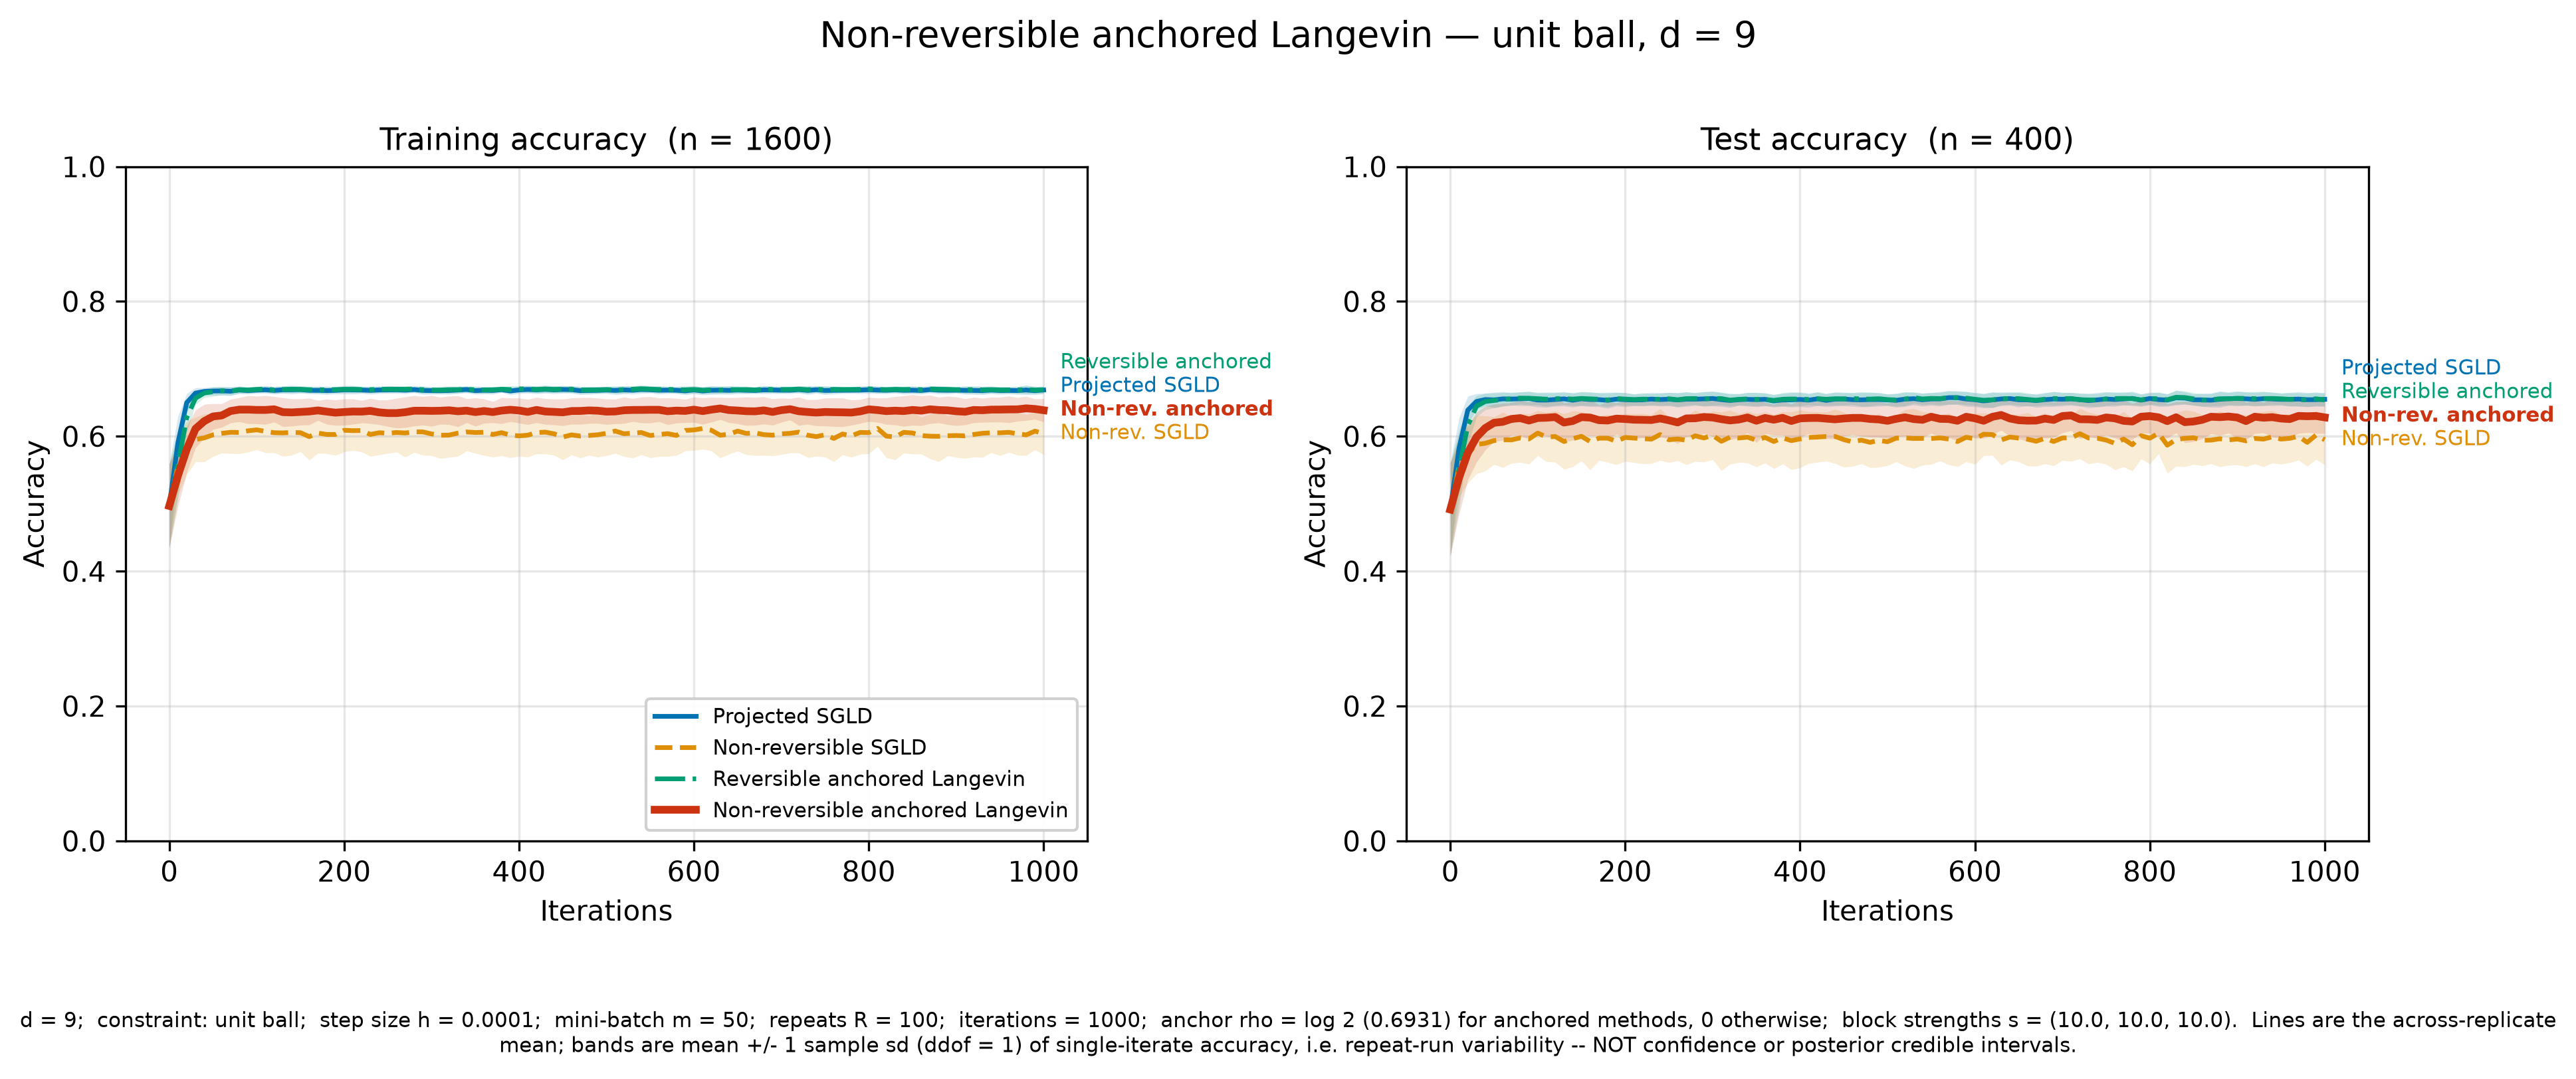

**quartic set**

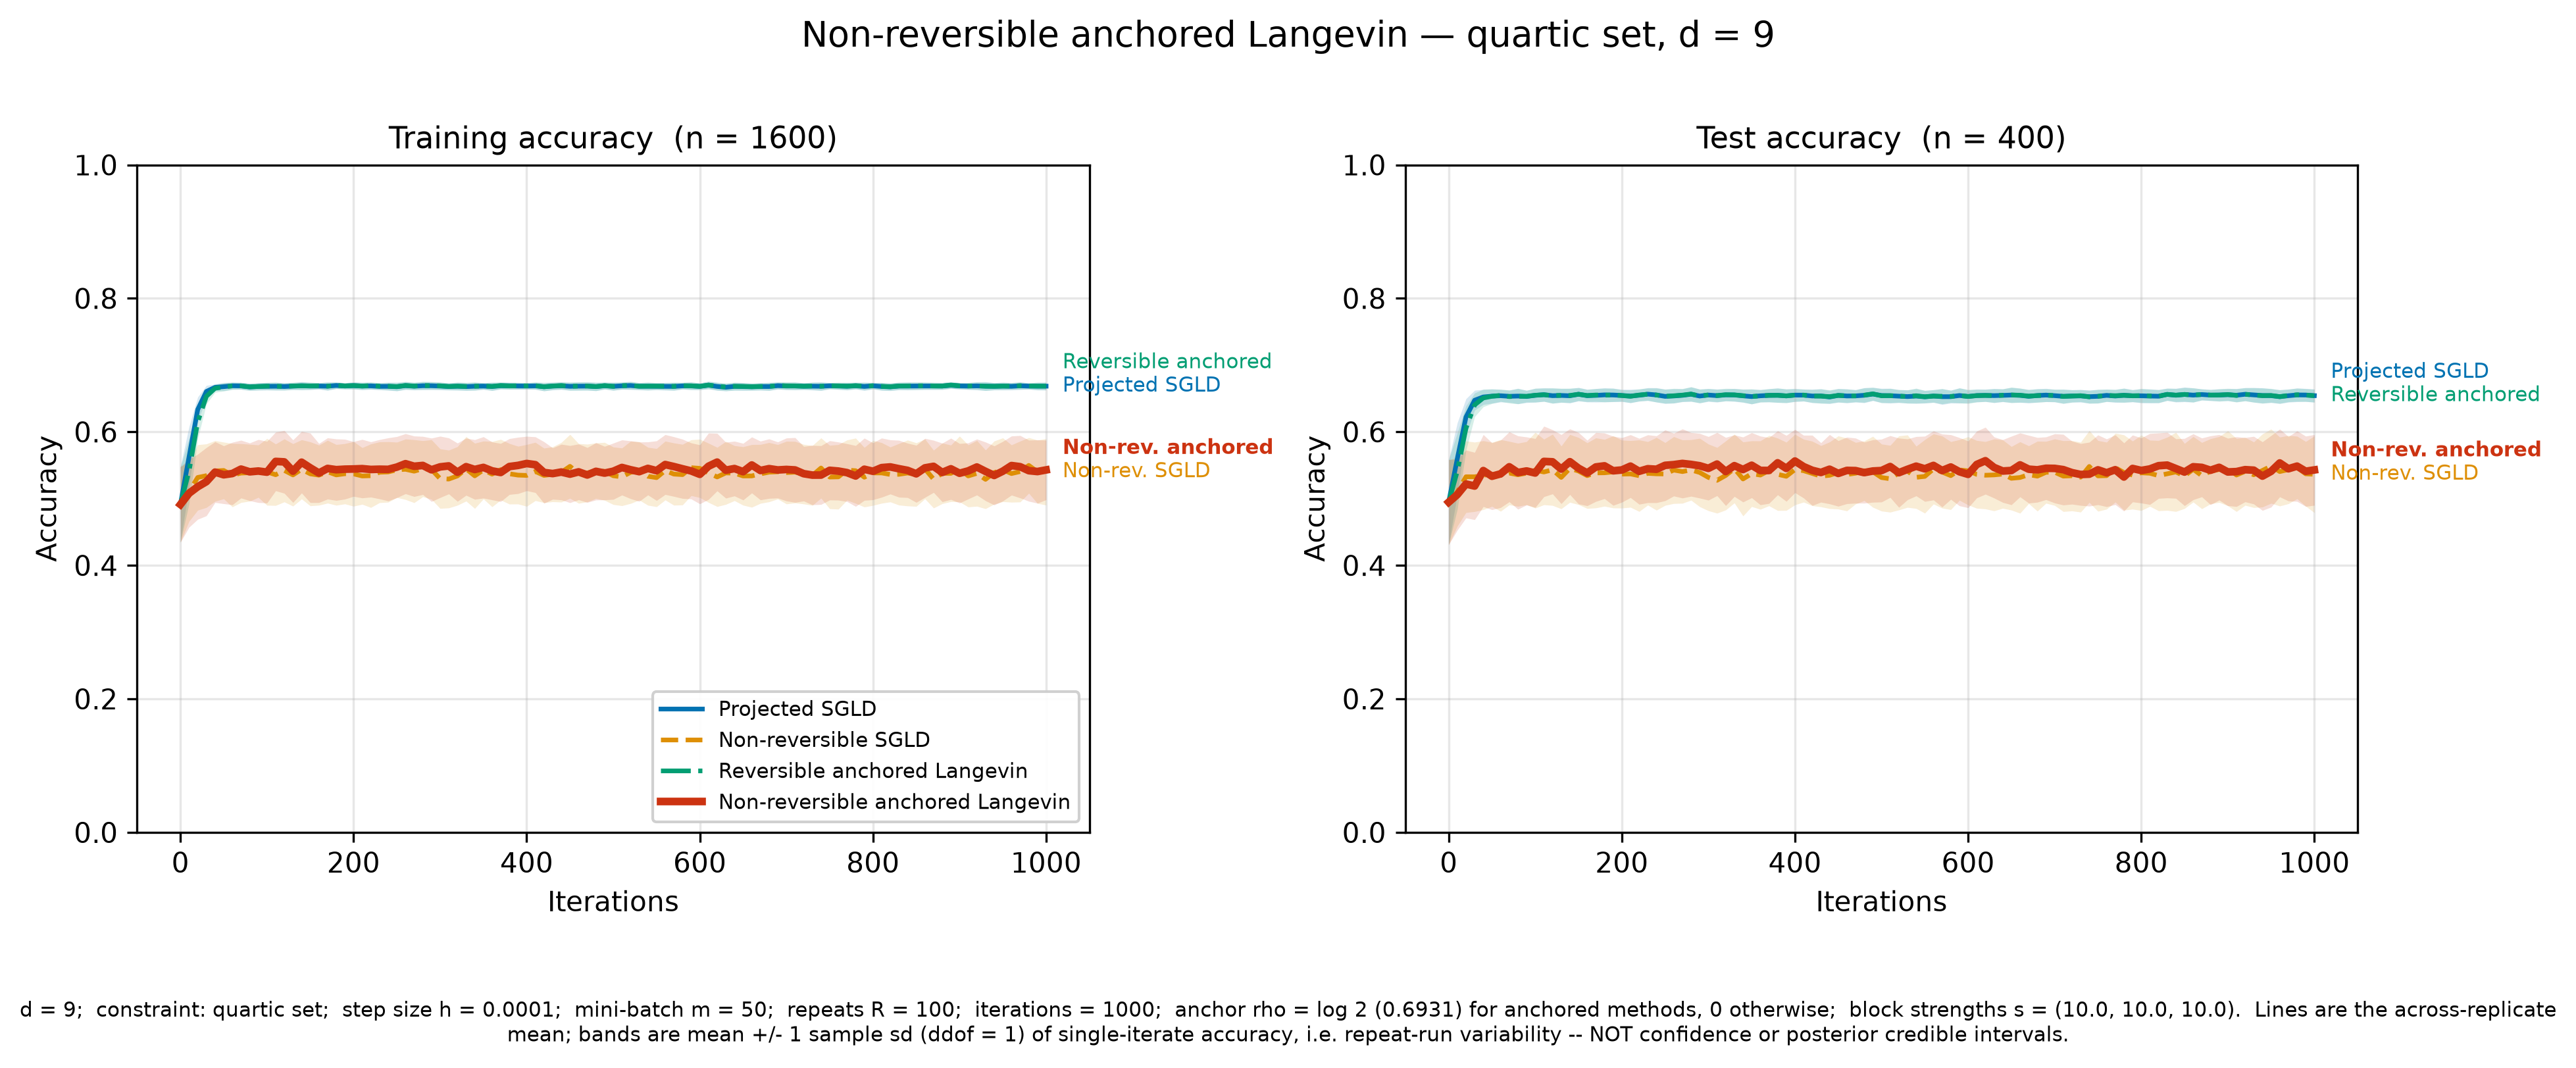

In [13]:
figure_paths = []
for geometry, tag in ((ball, "fig1_ball"), (quartic, "fig2_quartic")):
    runs = results[geometry.name]
    figure_paths += nral.plot_accuracy_figure(
        runs, cfg, geometry.name, OUTPUT_DIR, f"{tag}_d{cfg.d}{SUFFIX}",
        title_extra="" if not QUICK else "  [QUICK MODE]")
    # Supplementary companion on an auto-scaled axis. Same data, same code path;
    # the [0, 1] figure above is the required one.
    lows, highs = [], []
    for run in runs.values():
        for which in ("train_accuracy", "test_accuracy"):
            mean, sd = run.mean_std(which)
            lows.append((mean - sd).min()); highs.append((mean + sd).max())
    pad = 0.02
    figure_paths += nral.plot_accuracy_figure(
        runs, cfg, geometry.name, OUTPUT_DIR, f"{tag}_d{cfg.d}{SUFFIX}",
        ylim=(max(0.0, min(lows) - pad), min(1.0, max(highs) + pad)),
        title_extra="  (supplementary: auto-scaled axis)" + (" [QUICK MODE]" if QUICK else ""))

for path in figure_paths:
    print("wrote", path)
for geometry, tag in ((ball, "fig1_ball"), (quartic, "fig2_quartic")):
    display(Markdown(f"**{geometry.name}**"))
    display(__import__("IPython").display.Image(
        filename=os.path.join(OUTPUT_DIR, f"{tag}_d{cfg.d}{SUFFIX}.png"), width=980))

### 10a. Optional $d=3$ configuration

One block, $s=10$, saved separately from the $d=9$ results.

In [14]:
dataset_d3 = nral.make_dataset(cfg_d3)
ball_d3 = nral.make_geometry("ball", cfg_d3)
quartic_d3 = nral.make_geometry("quartic", cfg_d3)
print(f"beta_true_3 = {dataset_d3.beta_true.tolist()}")
print(f"  ||beta||^2 = {float(ball_d3.constraint_value(dataset_d3.beta_true)):.4f} <= 1")
print(f"  g(beta)    = {float(quartic_d3.constraint_value(dataset_d3.beta_true)):.4f} <= {cfg_d3.Lambda}")
print(f"  g_min = d*eps^4 = {quartic_d3.g_min:.4f}   (0.0048 for d=3)")
assert abs(quartic_d3.g_min - 0.0048) < 1e-12

results_d3 = {}
for geometry, tag in ((ball_d3, "figA_ball"), (quartic_d3, "figB_quartic")):
    results_d3[geometry.name] = nral.run_all_methods(dataset_d3, geometry, cfg_d3, verbose=False)
    figure_paths += nral.plot_accuracy_figure(
        results_d3[geometry.name], cfg_d3, geometry.name, OUTPUT_DIR,
        f"{tag}_d3{SUFFIX}", title_extra="  (optional d = 3)")
    frame = nral.summarise(results_d3[geometry.name], cfg_d3.target_accuracy)
    print(f"=== d = 3, {geometry.name} ({MODE}) ===")
    display(frame[["method", "final_train_acc", "final_test_acc", "final_test_sd",
                   "projection_rate", "drift_ratio_alphaJv_over_v"]])

beta_true_3 = [0.6, -0.3, 0.2]
  ||beta||^2 = 0.4900 <= 1
  g(beta)    = 0.1833 <= 1.0
  g_min = d*eps^4 = 0.0048   (0.0048 for d=3)


=== d = 3, unit ball (FULL EXPERIMENT) ===


,method,final_train_acc,final_test_acc,final_test_sd,projection_rate,drift_ratio_alphaJv_over_v
0,Projected SGLD,0.6770,0.6645,0.0079,0.0000,0.0000
1,Non-reversible SGLD,0.5779,0.5702,0.0554,0.7912,7.1875
2,Reversible anchored Langevin,0.6772,0.6643,0.0077,0.0000,0.0000
3,Non-reversible anchored Langevin,0.6161,0.6044,0.0441,0.3523,7.4412


=== d = 3, quartic set (FULL EXPERIMENT) ===


,method,final_train_acc,final_test_acc,final_test_sd,projection_rate,drift_ratio_alphaJv_over_v
0,Projected SGLD,0.6777,0.6637,0.0071,0.0000,0.0000
1,Non-reversible SGLD,0.5006,0.4995,0.0690,0.9669,20.8011
2,Reversible anchored Langevin,0.6779,0.6640,0.0076,0.0000,0.0000
3,Non-reversible anchored Langevin,0.4917,0.4931,0.0688,0.9136,21.0241


## 11. Step-size sensitivity and reproducibility

$h=10^{-4}$ is the paper's reported **candidate** setting, not a validated choice
for this modified sampler. Runs at $h/2$ and $h/4$ use 2000 and 4000 iterations so
that the total simulated time $t=kh$ is preserved; everything is compared against
$t$, not against the iteration index. The step size is common across methods
within each comparison.

The repeat count for this sweep is configurable and is disclosed in the caption.

In [15]:
sensitivity = {}
sens_repeats = cfg.sensitivity_repeats
for geometry in (ball, quartic):
    per_divisor = {}
    for divisor in cfg.sensitivity_divisors:
        per_divisor[divisor] = nral.run_all_methods(
            dataset, geometry, cfg,
            n_iterations=int(cfg.n_iterations * divisor),
            n_repeats=sens_repeats,
            step_size=cfg.step_size / divisor,
            checkpoint_every=int(cfg.checkpoint_every * divisor),
            verbose=False)
    sensitivity[geometry.name] = per_divisor
    print(f"[{MODE}] {geometry.name}: sensitivity done (R = {sens_repeats} per step size)")

rows = []
for label, per_divisor in sensitivity.items():
    for divisor, runs in per_divisor.items():
        for name, run in runs.items():
            moments = nral.coefficient_moments(run)
            mean, sd = run.mean_std("test_accuracy")
            rows.append({
                "geometry": label, "h_divisor": int(divisor), "step_size": run.step_size,
                "iterations": run.n_iterations, "method": name,
                "final_test_acc": mean[-1], "final_test_sd": sd[-1],
                "final_train_loss": run.train_loss[-1].mean(),
                "mean_||beta||": moments["norm_mean"][-1],
                "mean_coef_sd": moments["sd"][-1].mean(),
                "mean_constraint": run.constraint[-1].mean(),
                "projection_rate": run.projection_rate,
                "drift_ratio": run.drift_ratio,
                "step_displacement": run.step_displacement,
                "n_nonfinite": run.n_nonfinite,
            })
sensitivity_table = pd.DataFrame(rows)
for label in sensitivity:
    print(f"\n=== step-size sensitivity: {label}  ({MODE}, R = {sens_repeats}) ===")
    display(sensitivity_table[sensitivity_table.geometry == label].drop(columns="geometry")
            .sort_values(["method", "h_divisor"]))

[FULL EXPERIMENT] unit ball: sensitivity done (R = 20 per step size)


[FULL EXPERIMENT] quartic set: sensitivity done (R = 20 per step size)

=== step-size sensitivity: unit ball  (FULL EXPERIMENT, R = 20) ===


,h_divisor,step_size,iterations,method,final_test_acc,final_test_sd,final_train_loss,mean_||beta||,mean_coef_sd,mean_constraint,projection_rate,drift_ratio,step_displacement,n_nonfinite
1,1,0.0001,1000,Non-reversible SGLD,0.5900,0.0416,"1,157.1562",0.9916,0.2622,0.9835,0.5568,4.3920,0.2859,0
5,2,0.0001,2000,Non-reversible SGLD,0.6350,0.0256,"1,039.8141",0.8995,0.1677,0.8147,0.0204,4.0841,0.1105,0
9,4,0.0000,4000,Non-reversible SGLD,0.6469,0.0157,983.4425,0.7686,0.0792,0.5945,0.0000,3.5834,0.0469,0
3,1,0.0001,1000,Non-reversible anchored Langevin,0.6191,0.0226,"1,051.0049",0.9263,0.1765,0.8601,0.0345,4.2126,0.1328,0
7,2,0.0001,2000,Non-reversible anchored Langevin,0.6368,0.0154,999.8694,0.7979,0.1097,0.6401,0.0000,3.6955,0.0630,0
11,4,0.0000,4000,Non-reversible anchored Langevin,0.6465,0.0117,978.3678,0.7378,0.0697,0.5472,0.0000,3.4614,0.0324,0
0,1,0.0001,1000,Projected SGLD,0.6526,0.0109,972.3873,0.7025,0.0553,0.4959,0.0000,0.0000,0.0595,0
4,2,0.0001,2000,Projected SGLD,0.6573,0.0089,969.6500,0.7066,0.0473,0.5024,0.0000,0.0000,0.0361,0
8,4,0.0000,4000,Projected SGLD,0.6536,0.0074,969.2890,0.7043,0.0443,0.4987,0.0000,0.0000,0.0232,0
2,1,0.0001,1000,Reversible anchored Langevin,0.6520,0.0097,970.9569,0.7028,0.0502,0.4962,0.0000,0.0000,0.0462,0



=== step-size sensitivity: quartic set  (FULL EXPERIMENT, R = 20) ===


,h_divisor,step_size,iterations,method,final_test_acc,final_test_sd,final_train_loss,mean_||beta||,mean_coef_sd,mean_constraint,projection_rate,drift_ratio,step_displacement,n_nonfinite
13,1,0.0001,1000,Non-reversible SGLD,0.5361,0.0562,"1,468.5615",1.2219,0.3985,0.9854,0.8973,13.3898,1.1306,0
17,2,0.0001,2000,Non-reversible SGLD,0.5707,0.0529,"1,331.8952",1.1365,0.3569,0.8244,0.6629,12.0256,0.4962,0
21,4,0.0000,4000,Non-reversible SGLD,0.6464,0.0224,"1,011.8845",0.7787,0.1184,0.1826,0.1574,5.4192,0.1048,0
15,1,0.0001,1000,Non-reversible anchored Langevin,0.5544,0.0455,"1,422.7768",1.2396,0.3822,0.9761,0.7756,13.4275,0.5702,0
19,2,0.0001,2000,Non-reversible anchored Langevin,0.6049,0.0543,"1,202.9884",1.0687,0.2834,0.6389,0.3593,9.7350,0.2048,0
23,4,0.0000,4000,Non-reversible anchored Langevin,0.6536,0.0111,974.9418,0.7263,0.0623,0.1037,0.0081,2.2952,0.0344,0
12,1,0.0001,1000,Projected SGLD,0.6561,0.0095,973.2597,0.7052,0.0559,0.0988,0.0000,0.0000,0.0599,0
16,2,0.0001,2000,Projected SGLD,0.6554,0.0089,970.9324,0.7052,0.0505,0.0950,0.0000,0.0000,0.0363,0
20,4,0.0000,4000,Projected SGLD,0.6539,0.0103,968.1331,0.7152,0.0406,0.0976,0.0000,0.0000,0.0233,0
14,1,0.0001,1000,Reversible anchored Langevin,0.6554,0.0090,972.9702,0.7045,0.0551,0.0984,0.0000,0.0000,0.0571,0


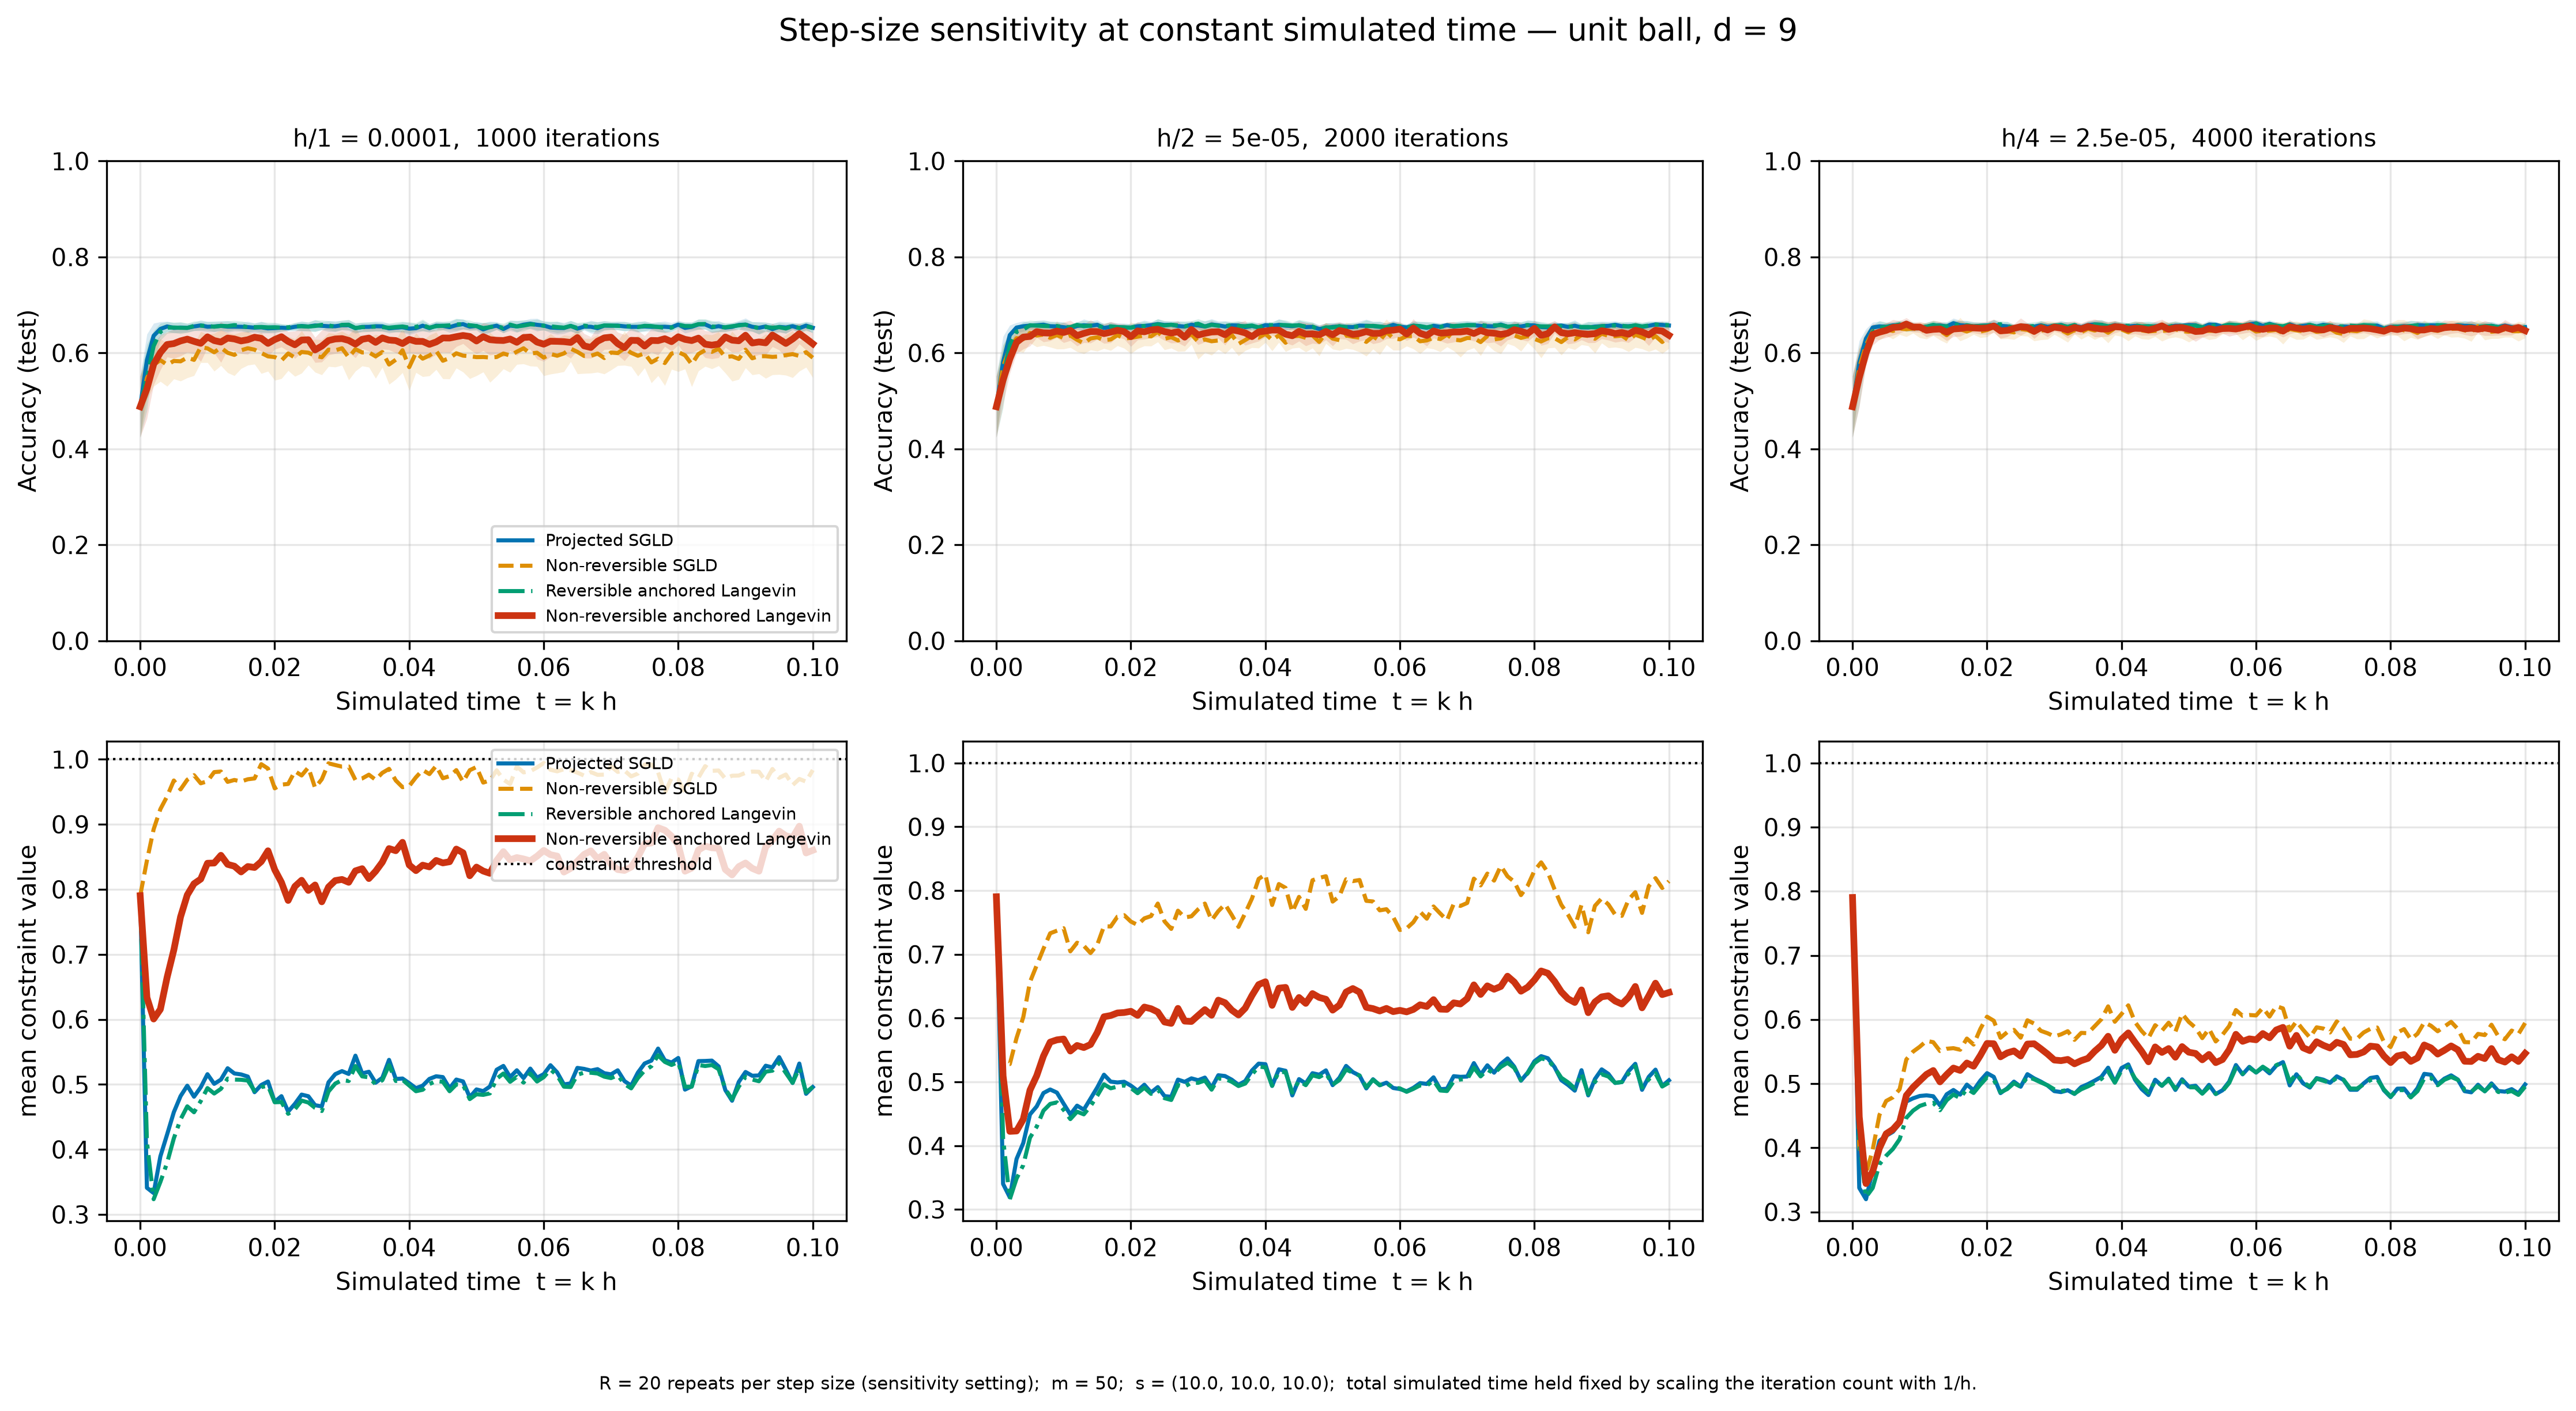

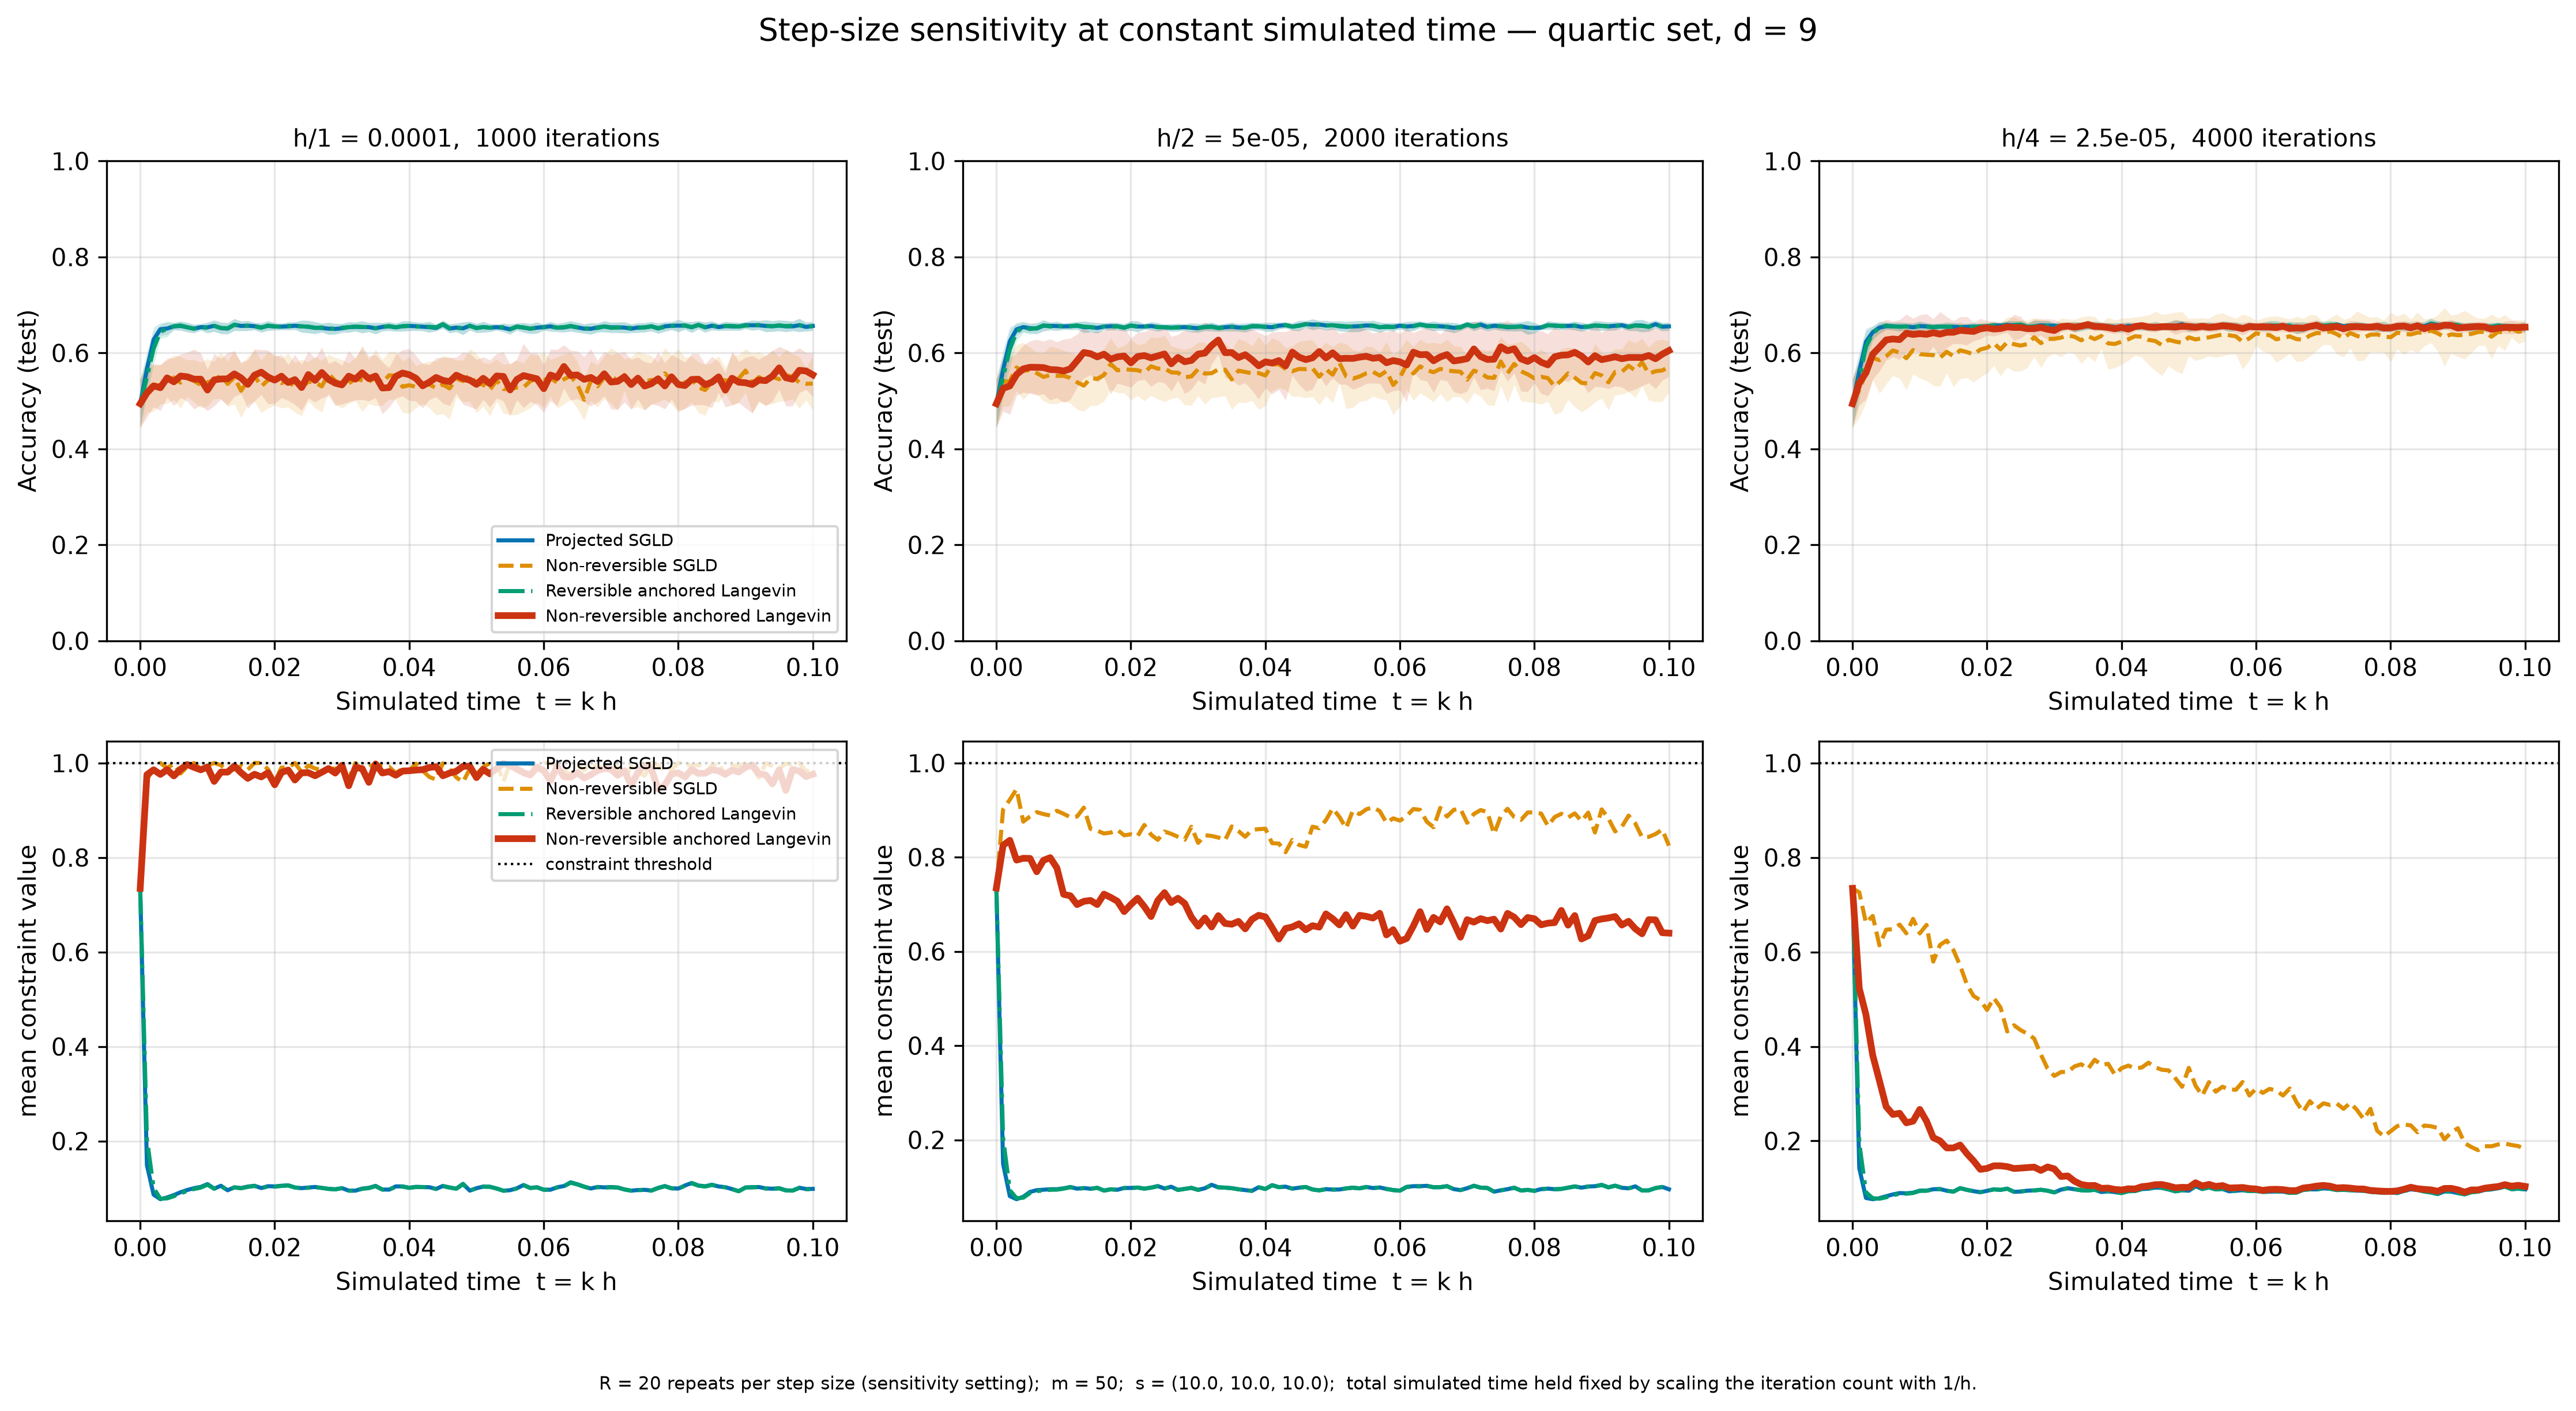

In [16]:
for geometry, tag in ((ball, "fig3_sensitivity_ball"), (quartic, "fig4_sensitivity_quartic")):
    figure_paths += nral.plot_sensitivity_figure(
        sensitivity[geometry.name], cfg, geometry.name, OUTPUT_DIR, f"{tag}_d{cfg.d}{SUFFIX}")
    display(__import__("IPython").display.Image(
        filename=os.path.join(OUTPUT_DIR, f"{tag}_d{cfg.d}{SUFFIX}.png"), width=980))

### 11a. Does the time-to-target conclusion survive step refinement?

In [17]:
verdict_rows = []
for label, per_divisor in sensitivity.items():
    for divisor, runs in per_divisor.items():
        frame = nral.summarise(runs, cfg.target_accuracy)
        best = frame.loc[frame["median_iters_to_target"].idxmin()] \
            if frame["median_iters_to_target"].notna().any() else None
        nral_row = frame[frame.method == "Non-reversible anchored Langevin"].iloc[0]
        base_row = frame[frame.method == "Projected SGLD"].iloc[0]
        verdict_rows.append({
            "geometry": label, "h_divisor": int(divisor),
            "fastest_to_target": None if best is None else best["method"],
            "NRAL_iters": nral_row["median_iters_to_target"],
            "SGLD_iters": base_row["median_iters_to_target"],
            "NRAL_secs": nral_row["median_secs_to_target"],
            "SGLD_secs": base_row["median_secs_to_target"],
            "NRAL_final_acc": nral_row["final_test_acc"],
            "SGLD_final_acc": base_row["final_test_acc"],
            "acc_gap_NRAL_minus_SGLD": nral_row["final_test_acc"] - base_row["final_test_acc"],
        })
verdict = pd.DataFrame(verdict_rows)
print(f"Stated target accuracy = {cfg.target_accuracy}   (test set; Bayes ceiling ~0.67)")
display(verdict)

Stated target accuracy = 0.64   (test set; Bayes ceiling ~0.67)


,geometry,h_divisor,fastest_to_target,NRAL_iters,SGLD_iters,NRAL_secs,SGLD_secs,NRAL_final_acc,SGLD_final_acc,acc_gap_NRAL_minus_SGLD
0,unit ball,1,Projected SGLD,60.0000,20.0000,0.0008,0.0002,0.6191,0.6526,-0.0335
1,unit ball,2,Projected SGLD,80.0000,40.0000,0.0009,0.0003,0.6368,0.6573,-0.0205
2,unit ball,4,Projected SGLD,160.0000,120.0000,0.0011,0.0006,0.6465,0.6536,-0.0071
3,quartic set,1,Projected SGLD,245.0000,30.0000,0.0314,0.0002,0.5544,0.6561,-0.1018
4,quartic set,2,Projected SGLD,380.0000,60.0000,0.0557,0.0003,0.6049,0.6554,-0.0505
5,quartic set,4,Projected SGLD,160.0000,120.0000,0.0032,0.0008,0.6536,0.6539,-0.0002


### 11b. Saved artefacts

Raw checkpoint accuracies, coefficient checkpoints, diagnostics, timings, the
configuration, seeds and package versions are written to disk so that every figure
can be regenerated without rerunning any sampler.

In [18]:
payload = dict(results)
payload.update({f"{k} [full-gradient control]": v for k, v in control.items()})
payload.update({f"{k} [d=3]": v for k, v in results_d3.items()})
for label, per_divisor in sensitivity.items():
    for divisor, runs in per_divisor.items():
        payload[f"{label} [h/{int(divisor)}]"] = runs

results_path = os.path.join(OUTPUT_DIR, f"results_d{cfg.d}{SUFFIX}.npz")
meta_path = nral.save_results(
    results_path, payload, cfg, dataset,
    extra={"mode": MODE, "quick": QUICK, "versions": VERSIONS,
           "checks": {k: {kk: float(vv) for kk, vv in v.items()} for k, v in checks.items()},
           "gradient_noise_report": noise_table.T.to_dict(),
           "target_accuracy": cfg.target_accuracy,
           "sensitivity_repeats": sens_repeats,
           "figures": sorted(set(figure_paths))})
# Per-checkpoint mean and sample sd, saved explicitly (not merely derivable).
curve_rows = []
labelled = {**{k: v for k, v in results.items()},
            **{f"{k} [d=3]": v for k, v in results_d3.items()}}
for label, runs in labelled.items():
    for name, run in runs.items():
        train_mean, train_sd = run.mean_std("train_accuracy")
        test_mean, test_sd = run.mean_std("test_accuracy")
        for i, iteration in enumerate(run.checkpoints):
            curve_rows.append({
                "geometry": label, "method": name, "iteration": int(iteration),
                "simulated_time": float(iteration * run.step_size),
                "train_acc_mean": train_mean[i], "train_acc_sd": train_sd[i],
                "test_acc_mean": test_mean[i], "test_acc_sd": test_sd[i],
                "n_repeats": run.n_repeats})
accuracy_curves = pd.DataFrame(curve_rows)
accuracy_curves.to_csv(
    os.path.join(OUTPUT_DIR, f"accuracy_curves_mean_sd{SUFFIX}.csv"), index=False)
print(f"accuracy_curves_mean_sd{SUFFIX}.csv: {len(accuracy_curves)} rows "
      f"(per checkpoint, per method, per geometry)")

# Per-checkpoint mean and sample sd, saved explicitly (not merely derivable).
curve_rows = []
labelled = {**dict(results), **{f"{k} [d=3]": v for k, v in results_d3.items()}}
for label, runs in labelled.items():
    for name, run in runs.items():
        train_mean, train_sd = run.mean_std("train_accuracy")
        test_mean, test_sd = run.mean_std("test_accuracy")
        for i, iteration in enumerate(run.checkpoints):
            curve_rows.append({
                "geometry": label, "method": name, "iteration": int(iteration),
                "simulated_time": float(iteration * run.step_size),
                "train_acc_mean": train_mean[i], "train_acc_sd": train_sd[i],
                "test_acc_mean": test_mean[i], "test_acc_sd": test_sd[i],
                "n_repeats": run.n_repeats})
accuracy_curves = pd.DataFrame(curve_rows)
accuracy_curves.to_csv(os.path.join(OUTPUT_DIR, f"accuracy_curves_mean_sd{SUFFIX}.csv"), index=False)
print(f"accuracy_curves_mean_sd{SUFFIX}.csv: {len(accuracy_curves)} rows")

sensitivity_table.to_csv(os.path.join(OUTPUT_DIR, f"sensitivity_d{cfg.d}{SUFFIX}.csv"), index=False)
sweep_table.to_csv(os.path.join(OUTPUT_DIR, f"block_strength_sweep_d{cfg.d}{SUFFIX}.csv"), index=False)
verdict.to_csv(os.path.join(OUTPUT_DIR, f"time_to_target_d{cfg.d}{SUFFIX}.csv"), index=False)
for label, frame in summaries.items():
    frame.to_csv(os.path.join(OUTPUT_DIR,
                 f"summary_{label.replace(' ', '_')}_d{cfg.d}{SUFFIX}.csv"), index=False)
print("saved:", results_path); print("saved:", meta_path)
print("\n".join(sorted(os.listdir(OUTPUT_DIR))))

accuracy_curves_mean_sd.csv: 1616 rows (per checkpoint, per method, per geometry)
accuracy_curves_mean_sd.csv: 1616 rows
saved: results/results_d9.npz
saved: results/results_d9_metadata.json
accuracy_curves_mean_sd.csv
block_strength_sweep_d9.csv
fig1_ball_d9.pdf
fig1_ball_d9.png
fig1_ball_d9_zoom.pdf
fig1_ball_d9_zoom.png
fig2_quartic_d9.pdf
fig2_quartic_d9.png
fig2_quartic_d9_zoom.pdf
fig2_quartic_d9_zoom.png
fig3_sensitivity_ball_d9.pdf
fig3_sensitivity_ball_d9.png
fig4_sensitivity_quartic_d9.pdf
fig4_sensitivity_quartic_d9.png
figA_ball_d3.pdf
figA_ball_d3.png
figB_quartic_d3.pdf
figB_quartic_d3.png
results_d9.npz
results_d9_metadata.json
sensitivity_d9.csv
summary_quartic_set_d9.csv
summary_unit_ball_d9.csv
time_to_target_d9.csv


### 11c. Figures are regenerable without rerunning any sampler

Reload the saved arrays from disk, rebuild the result objects and redraw a main
figure. Nothing below touches a sampler.

In [19]:
loaded = np.load(results_path)

def rebuild(geometry_label, method_name, reference):
    # Reconstruct a RunResult from the saved arrays alone.
    key = f"{geometry_label}|{method_name}".replace(" ", "_")
    return nral.RunResult(
        method=method_name, geometry=geometry_label,
        rho=reference.rho, alpha=reference.alpha, step_size=reference.step_size,
        n_iterations=reference.n_iterations, n_repeats=reference.n_repeats,
        block_scales=reference.block_scales,
        checkpoints=loaded[f"{key}|checkpoints"],
        train_accuracy=loaded[f"{key}|train_accuracy"],
        test_accuracy=loaded[f"{key}|test_accuracy"],
        beta=loaded[f"{key}|beta"], train_loss=loaded[f"{key}|train_loss"],
        constraint=loaded[f"{key}|constraint"], anchor=loaded[f"{key}|anchor"],
        projection_rate=reference.projection_rate,
        max_kkt_residual=reference.max_kkt_residual,
        max_feasibility_excess=reference.max_feasibility_excess,
        n_nonfinite=reference.n_nonfinite, runtime=reference.runtime)

restored = {name: rebuild(ball.name, name, run) for name, run in results[ball.name].items()}
regenerated = nral.plot_accuracy_figure(
    restored, cfg, ball.name, OUTPUT_DIR, f"fig1_ball_d{cfg.d}{SUFFIX}_regenerated",
    title_extra="  (regenerated from saved arrays)")
worst = max(
    float(np.abs(restored[name].test_accuracy - results[ball.name][name].test_accuracy).max())
    for name in restored)
print(f"max |reloaded - in-memory| test accuracy: {worst:.3e}")
assert worst == 0.0, "saved arrays do not reproduce the in-memory results"
print("Figures regenerate exactly from disk:", regenerated)

max |reloaded - in-memory| test accuracy: 0.000e+00
Figures regenerate exactly from disk: ['results/fig1_ball_d9_regenerated.png', 'results/fig1_ball_d9_regenerated.pdf']


## 12. Interpretation and limitations

*(Filled in from the executed numbers above — see the printed cell below, which is
generated from the results rather than written by hand.)*

In [20]:
lines = []
for label in results:
    frame = summaries[label]
    base = frame[frame.method == "Projected SGLD"].iloc[0]
    rev = frame[frame.method == "Reversible anchored Langevin"].iloc[0]
    nr = frame[frame.method == "Non-reversible anchored Langevin"].iloc[0]
    lines.append(f"{label}:")
    lines.append(f"  final test accuracy   projected SGLD {base.final_test_acc:.4f}"
                 f" +/- {base.final_test_sd:.4f} | reversible anchored {rev.final_test_acc:.4f}"
                 f" +/- {rev.final_test_sd:.4f} | non-rev anchored {nr.final_test_acc:.4f}"
                 f" +/- {nr.final_test_sd:.4f}")
    lines.append(f"  projection rate       {base.projection_rate:.3f} | {rev.projection_rate:.3f}"
                 f" | {nr.projection_rate:.3f}")
    lines.append(f"  ||alpha J v||/||v||   {nr.drift_ratio_alphaJv_over_v:.2f} for the non-reversible anchored run")
print("\n".join(lines))
print()
refined = verdict[verdict.h_divisor == max(verdict.h_divisor)]
coarse = verdict[verdict.h_divisor == 1]
print(f"Accuracy gap (non-rev anchored minus projected SGLD), test set:")
for _, row in coarse.iterrows():
    print(f"  {row.geometry:<12} at h      : {row.acc_gap_NRAL_minus_SGLD:+.4f}")
for _, row in refined.iterrows():
    print(f"  {row.geometry:<12} at h/{row.h_divisor}    : {row.acc_gap_NRAL_minus_SGLD:+.4f}")

unit ball:
  final test accuracy   projected SGLD 0.6548 +/- 0.0102 | reversible anchored 0.6540 +/- 0.0095 | non-rev anchored 0.6281 +/- 0.0238
  projection rate       0.000 | 0.000 | 0.041
  ||alpha J v||/||v||   4.23 for the non-reversible anchored run
quartic set:
  final test accuracy   projected SGLD 0.6543 +/- 0.0099 | reversible anchored 0.6541 +/- 0.0096 | non-rev anchored 0.5429 +/- 0.0529
  projection rate       0.000 | 0.000 | 0.767
  ||alpha J v||/||v||   13.34 for the non-reversible anchored run

Accuracy gap (non-rev anchored minus projected SGLD), test set:
  unit ball    at h      : -0.0335
  quartic set  at h      : -0.1018
  unit ball    at h/4    : -0.0071
  quartic set  at h/4    : -0.0002


### What was observed

At the candidate step size $h=10^{-4}$ with $s=(10,10,10)$, **the non-reversible
methods are worse on this accuracy metric**, on both geometries, and the anchored
and unanchored reversible methods are indistinguishable from each other. This is
reported as measured; it is not evidence against non-reversible sampling in
general.

The diagnosis is a step-size failure specific to the modified sampler, and the
notebook supports it with three independent pieces of evidence:

1. **The added term dominates the update.** $\|\alpha Jv\|/\|v\|$ is measured to be
   an order of magnitude above 1, and the mean per-step displacement is a
   substantial fraction of the domain radius. The projection then fires on a large
   fraction of iterations — the chain is being pushed into the boundary, not
   circulated within the interior.
2. **Mini-batch noise is amplified.** $J$ multiplies the gradient *error* as well
   as the gradient. The measured amplification and the resulting per-step
   displacement dwarf the injected $\sqrt{2ha}$ increment, so the added term
   changes the effective noise level rather than acting as a mean-zero
   perturbation. The full-gradient control removes this component.
3. **Refinement removes the gap.** Under $h/2$ and $h/4$ at constant simulated
   time the projection rate collapses and the accuracy deficit closes.

So the answer to "which method reaches the stated accuracy sooner, and does that
conclusion survive step refinement?" is: **at $h=10^{-4}$ the reversible methods
are faster, and that conclusion does not survive step refinement** — the methods
become comparable once the step is small enough for the $\alpha Jv$ term.

### Limitations

* **Accuracy is not posterior convergence.** These are single-iterate
  classification accuracies. They say nothing about whether the sampler has
  reached $\pi_K$, nor about asymptotic variance. A method could match on accuracy
  and still be badly biased.
* **The invariance identity does not cover this algorithm.** It holds for the
  continuous-time process with the exact gradient. The implementation adds three
  uncontrolled biases: finite $h$, mini-batch gradient noise, and the projection,
  which places mass on $\partial K$ and is not a discretisation of a
  measure-preserving reflected process.
* **Bounded iterates prove nothing.** $\Pi_K$ keeps every state in $K$ by
  construction, so the absence of blow-up is not evidence of numerical accuracy.
  Projection rates and non-finite counts are reported for exactly this reason.
* **One data set, one split, one $\beta_{\text{true}}$.** The replicate spread is
  sampler randomness *conditional on* this fixed data set; it does not include
  data-sampling variability.
* **Bands are repeat-run variability.** Not confidence intervals, not credible
  intervals.
* **The comparison is at fixed $(h, s)$.** $s$ was not tuned; the sweep in §9c
  shows the mechanism but is not a recommendation. Nothing was tuned against test
  labels, the $n_{\text{train}}/m$ factor was never removed, the drift was never
  clipped, and $J$ was never rescaled.